# Exploratory Data Analysis

## Dataset

The dataset is available at [KuaiRec](https://nas.chongminggao.top:4430/datasets/KuaiRec.zip).

We can download the dataset via a wget command:

In [1]:
%%bash
if [ ! -d "../data_final_project" ]; then
  wget --no-check-certificate 'https://drive.usercontent.google.com/download?id=1qe5hOSBxzIuxBb1G_Ih5X-O65QElollE&export=download&confirm=t&uuid=b2002093-cc6e-4bd5-be47-9603f0b33470' -O KuaiRec.zip
  unzip KuaiRec.zip -d ../data_final_project
else
  echo "Directory '../data_final_project' already exists. Skipping download."
fi

Directory '../data_final_project' already exists. Skipping download.


In [2]:
import pandas as pd
import numpy as np
from langdetect import detect
import re
import matplotlib.pyplot as plt
import seaborn as sns

# set plot size
plt.rcParams["figure.figsize"] = (20, 13)
%matplotlib inline
%config InlineBackend.figure_format = "retina"

# **1️⃣ Exploratory Data Analysis - Interactions**

🔍 For this data analysis, we will focus on the interaction data, i.e., the data that contains the user-item interactions.

## 💎 Data Preprocessing

In [3]:
interactions = pd.read_csv("../data_final_project/KuaiRec/data/small_matrix.csv")

interactions.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,1.593898e+09,0.722103
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,1.593898e+09,1.907377
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,1.593898e+09,2.063311
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,1.593898e+09,0.566388
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,1.593899e+09,0.418364


```Description of the columns present in the dataset :```
| Field Name                | Description                                      | Type   | Example                                                                 |
|---------------------------|--------------------------------------------------|--------|-------------------------------------------------------------------------|
| user_id                   | The ID of the user.                             | int64  | 0                                                                      |
| video_id                  | The ID of the viewed video.                     | int64  | 3650                                                                  |
| play_duration             | Time of video viewing of this interaction (millisecond). | int64  | 13838                                                                 |
| video_duration            | Time of this video (millisecond).              | int64  | 10867                                                                 |
| time                      | Human-readable date for this interaction       | str    | "2020-07-05 00:08:23.438"                                              |
| date                      | Date of this interaction                       | int64  | 20200705                                                              |
| timestamp                 | Unix timestamp                                 | float64| 1593878903.438                                                        |
| watch_ratio              | The video watching ratio (=play_duration/video_duration) | float64| 1.273397                                                            |


In [4]:
interactions = interactions.dropna()
interactions = interactions.drop_duplicates()
interactions = interactions[interactions["timestamp"] >= 0]

In [5]:
interactions.columns

Index(['user_id', 'video_id', 'play_duration', 'video_duration', 'time',
       'date', 'timestamp', 'watch_ratio'],
      dtype='object')

In [6]:
interactions.isnull().sum()

user_id           0
video_id          0
play_duration     0
video_duration    0
time              0
date              0
timestamp         0
watch_ratio       0
dtype: int64

## ❓Basic Questions

In [7]:
print("What are the data types?")
print(interactions.dtypes)

print("\nHow many interactions are there in the data?")
display(interactions.shape[0])

print("\nHow many unique users and unique videos?")
print("Nbr of unique user id: " + str(interactions['user_id'].nunique()))
print("Nbr of unique video id: " + str(interactions['video_id'].nunique()))

print("\nAre there timestamps, and if so, what is their range?")
# interactions['timestamp'] = pd.to_datetime(interactions['timestamp']) => not needed apparently
display(interactions['timestamp'].agg(['min', 'max']))
print(pd.to_datetime(1.592872e+09, unit='s'))
print(pd.to_datetime(1.599694e+09, unit='s'))

What are the data types?
user_id             int64
video_id            int64
play_duration       int64
video_duration      int64
time               object
date              float64
timestamp         float64
watch_ratio       float64
dtype: object

How many interactions are there in the data?


4494578


How many unique users and unique videos?
Nbr of unique user id: 1411
Nbr of unique video id: 3327

Are there timestamps, and if so, what is their range?


min    1.593801e+09
max    1.599321e+09
Name: timestamp, dtype: float64

2020-06-23 00:26:40
2020-09-09 23:26:40


We can see that the data range is around the covid pandemic quarantine time, which can pump a little bit the number of interactions as more people were engaged on social media than before or after this period.

## 📊 Basic Statistics & Distributions

### 💬 Interactions per User

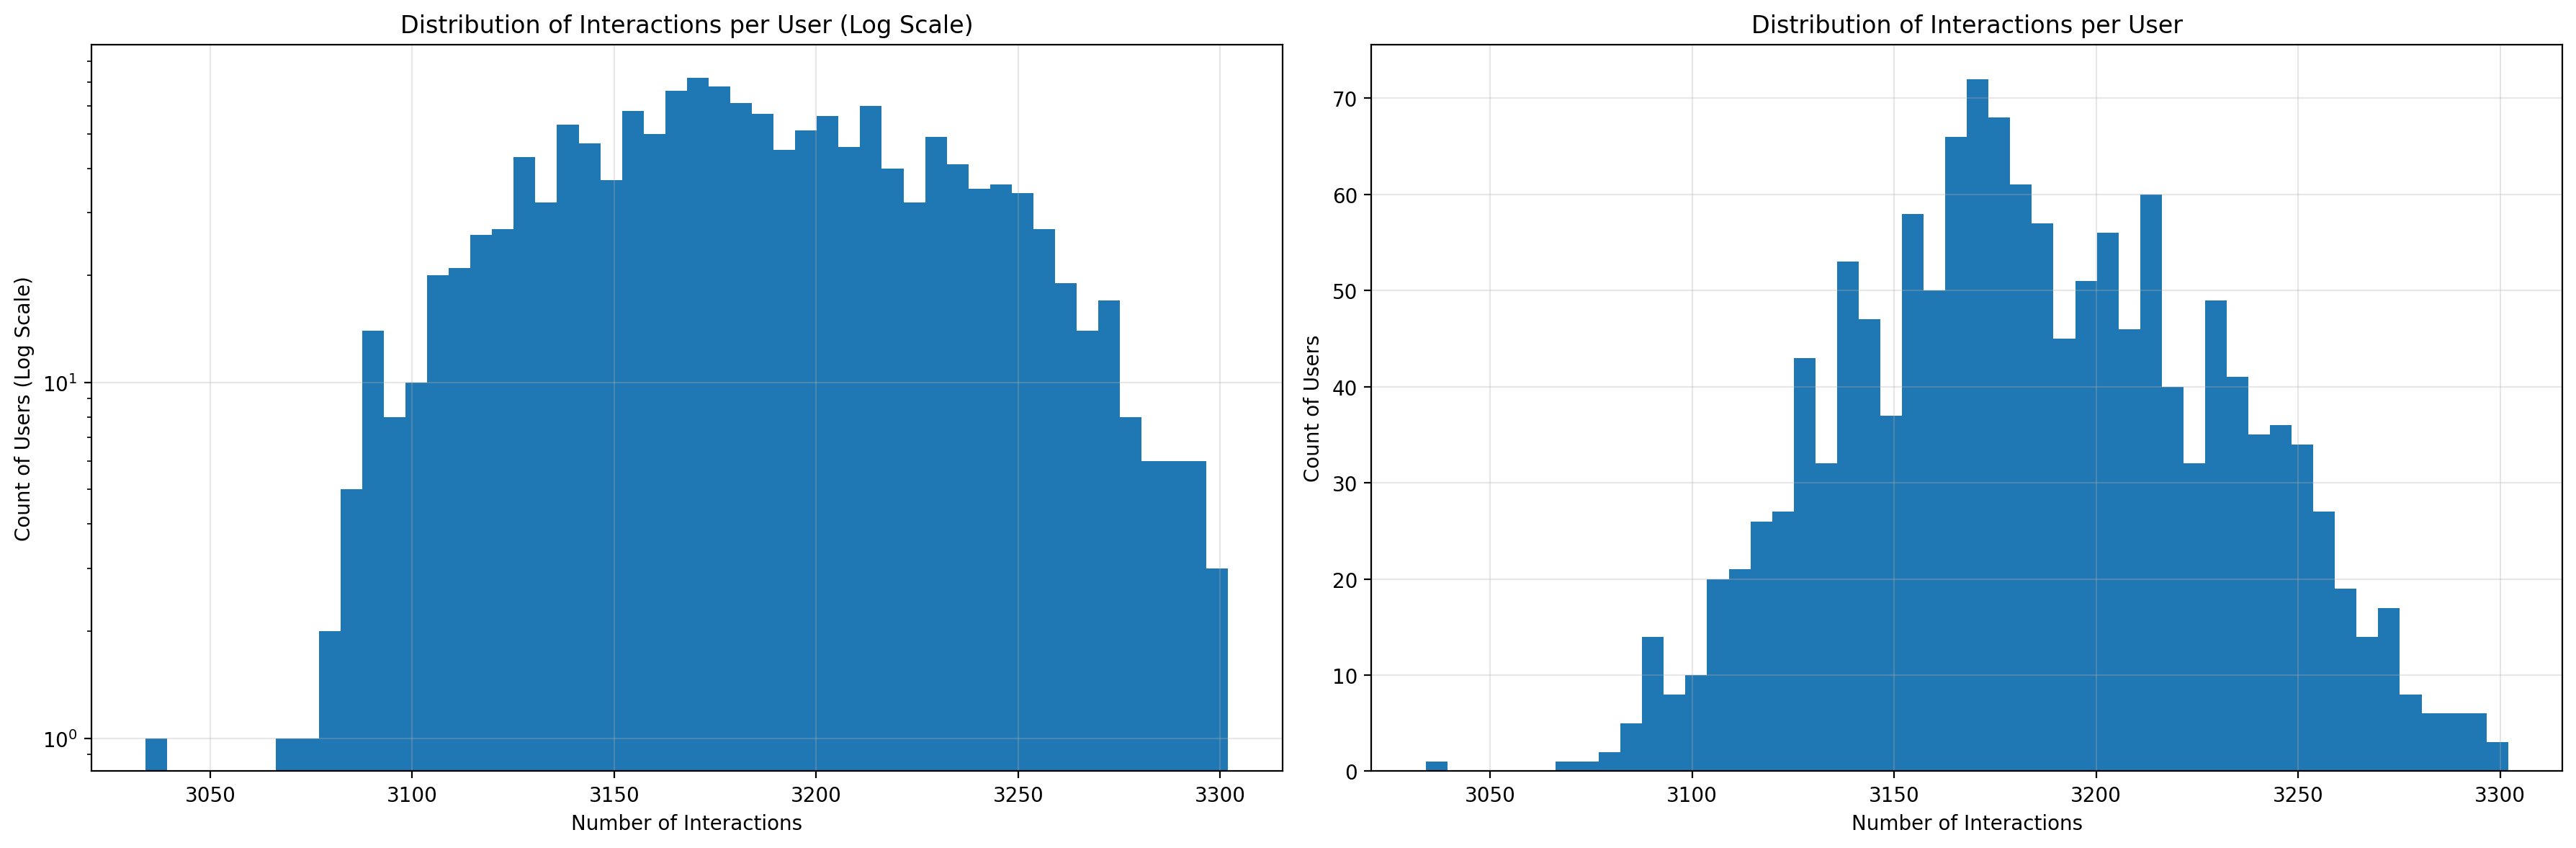

In [8]:
user_counts = interactions["user_id"].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

axs[0].hist(user_counts, bins=50, log=True)
axs[0].set_title("Distribution of Interactions per User (Log Scale)")
axs[0].set_xlabel("Number of Interactions")
axs[0].set_ylabel("Count of Users (Log Scale)")
axs[0].grid(True, alpha=0.3)

axs[1].hist(user_counts, bins=50)
axs[1].set_title("Distribution of Interactions per User")
axs[1].set_xlabel("Number of Interactions")
axs[1].set_ylabel("Count of Users")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Thinking 🤔
From these two graphs above we can see that :
- Most of users have **less than 3000 interactions**
- There are **some outliers** having more than 6000.

We could think that most of the users are passive, meaning they won't interact much with the videos.

### 💬 Interactions per item

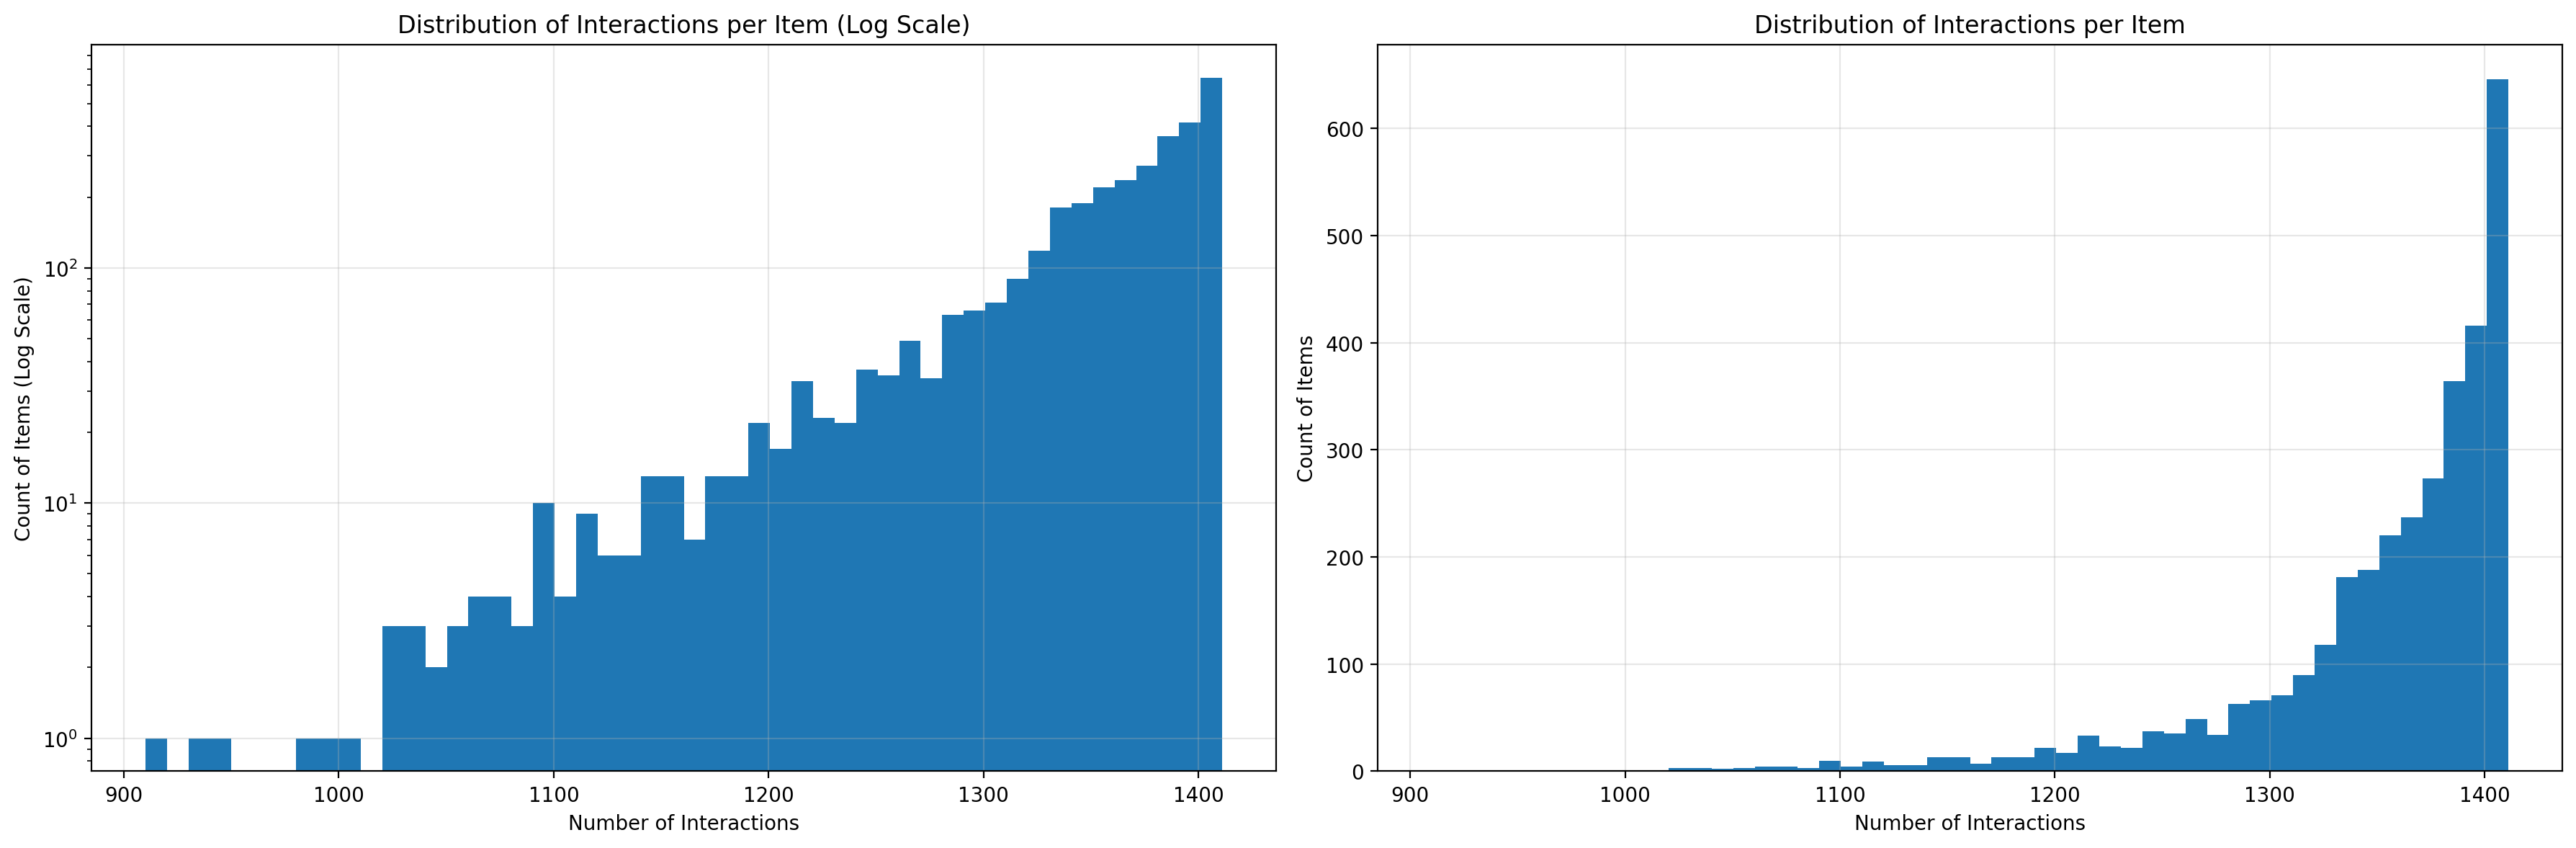

In [9]:
item_counts = interactions["video_id"].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

axs[0].hist(item_counts, bins=50, log=True)
axs[0].set_title("Distribution of Interactions per Item (Log Scale)")
axs[0].set_xlabel("Number of Interactions")
axs[0].set_ylabel("Count of Items (Log Scale)")
axs[0].grid(True, alpha=0.3)

axs[1].hist(item_counts, bins=50)
axs[1].set_title("Distribution of Interactions per Item")
axs[1].set_xlabel("Number of Interactions")
axs[1].set_ylabel("Count of Items")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Thinking 🤔
From these two graphs above we can see that :
- There are very **few items with a lot of interactions**.
- A lot of these items that are considered as not unpopular, and few of them are really popular.

This might indicate that **serendipity** will be an important metric in our future recommender systems.

The recommender systems should be able to manage novelty and "hidden gems", some videos that are unpopular but that could match the user's interests.

### ⏰ Temporal Analysis

Let's see the distribution of the interactions over time.

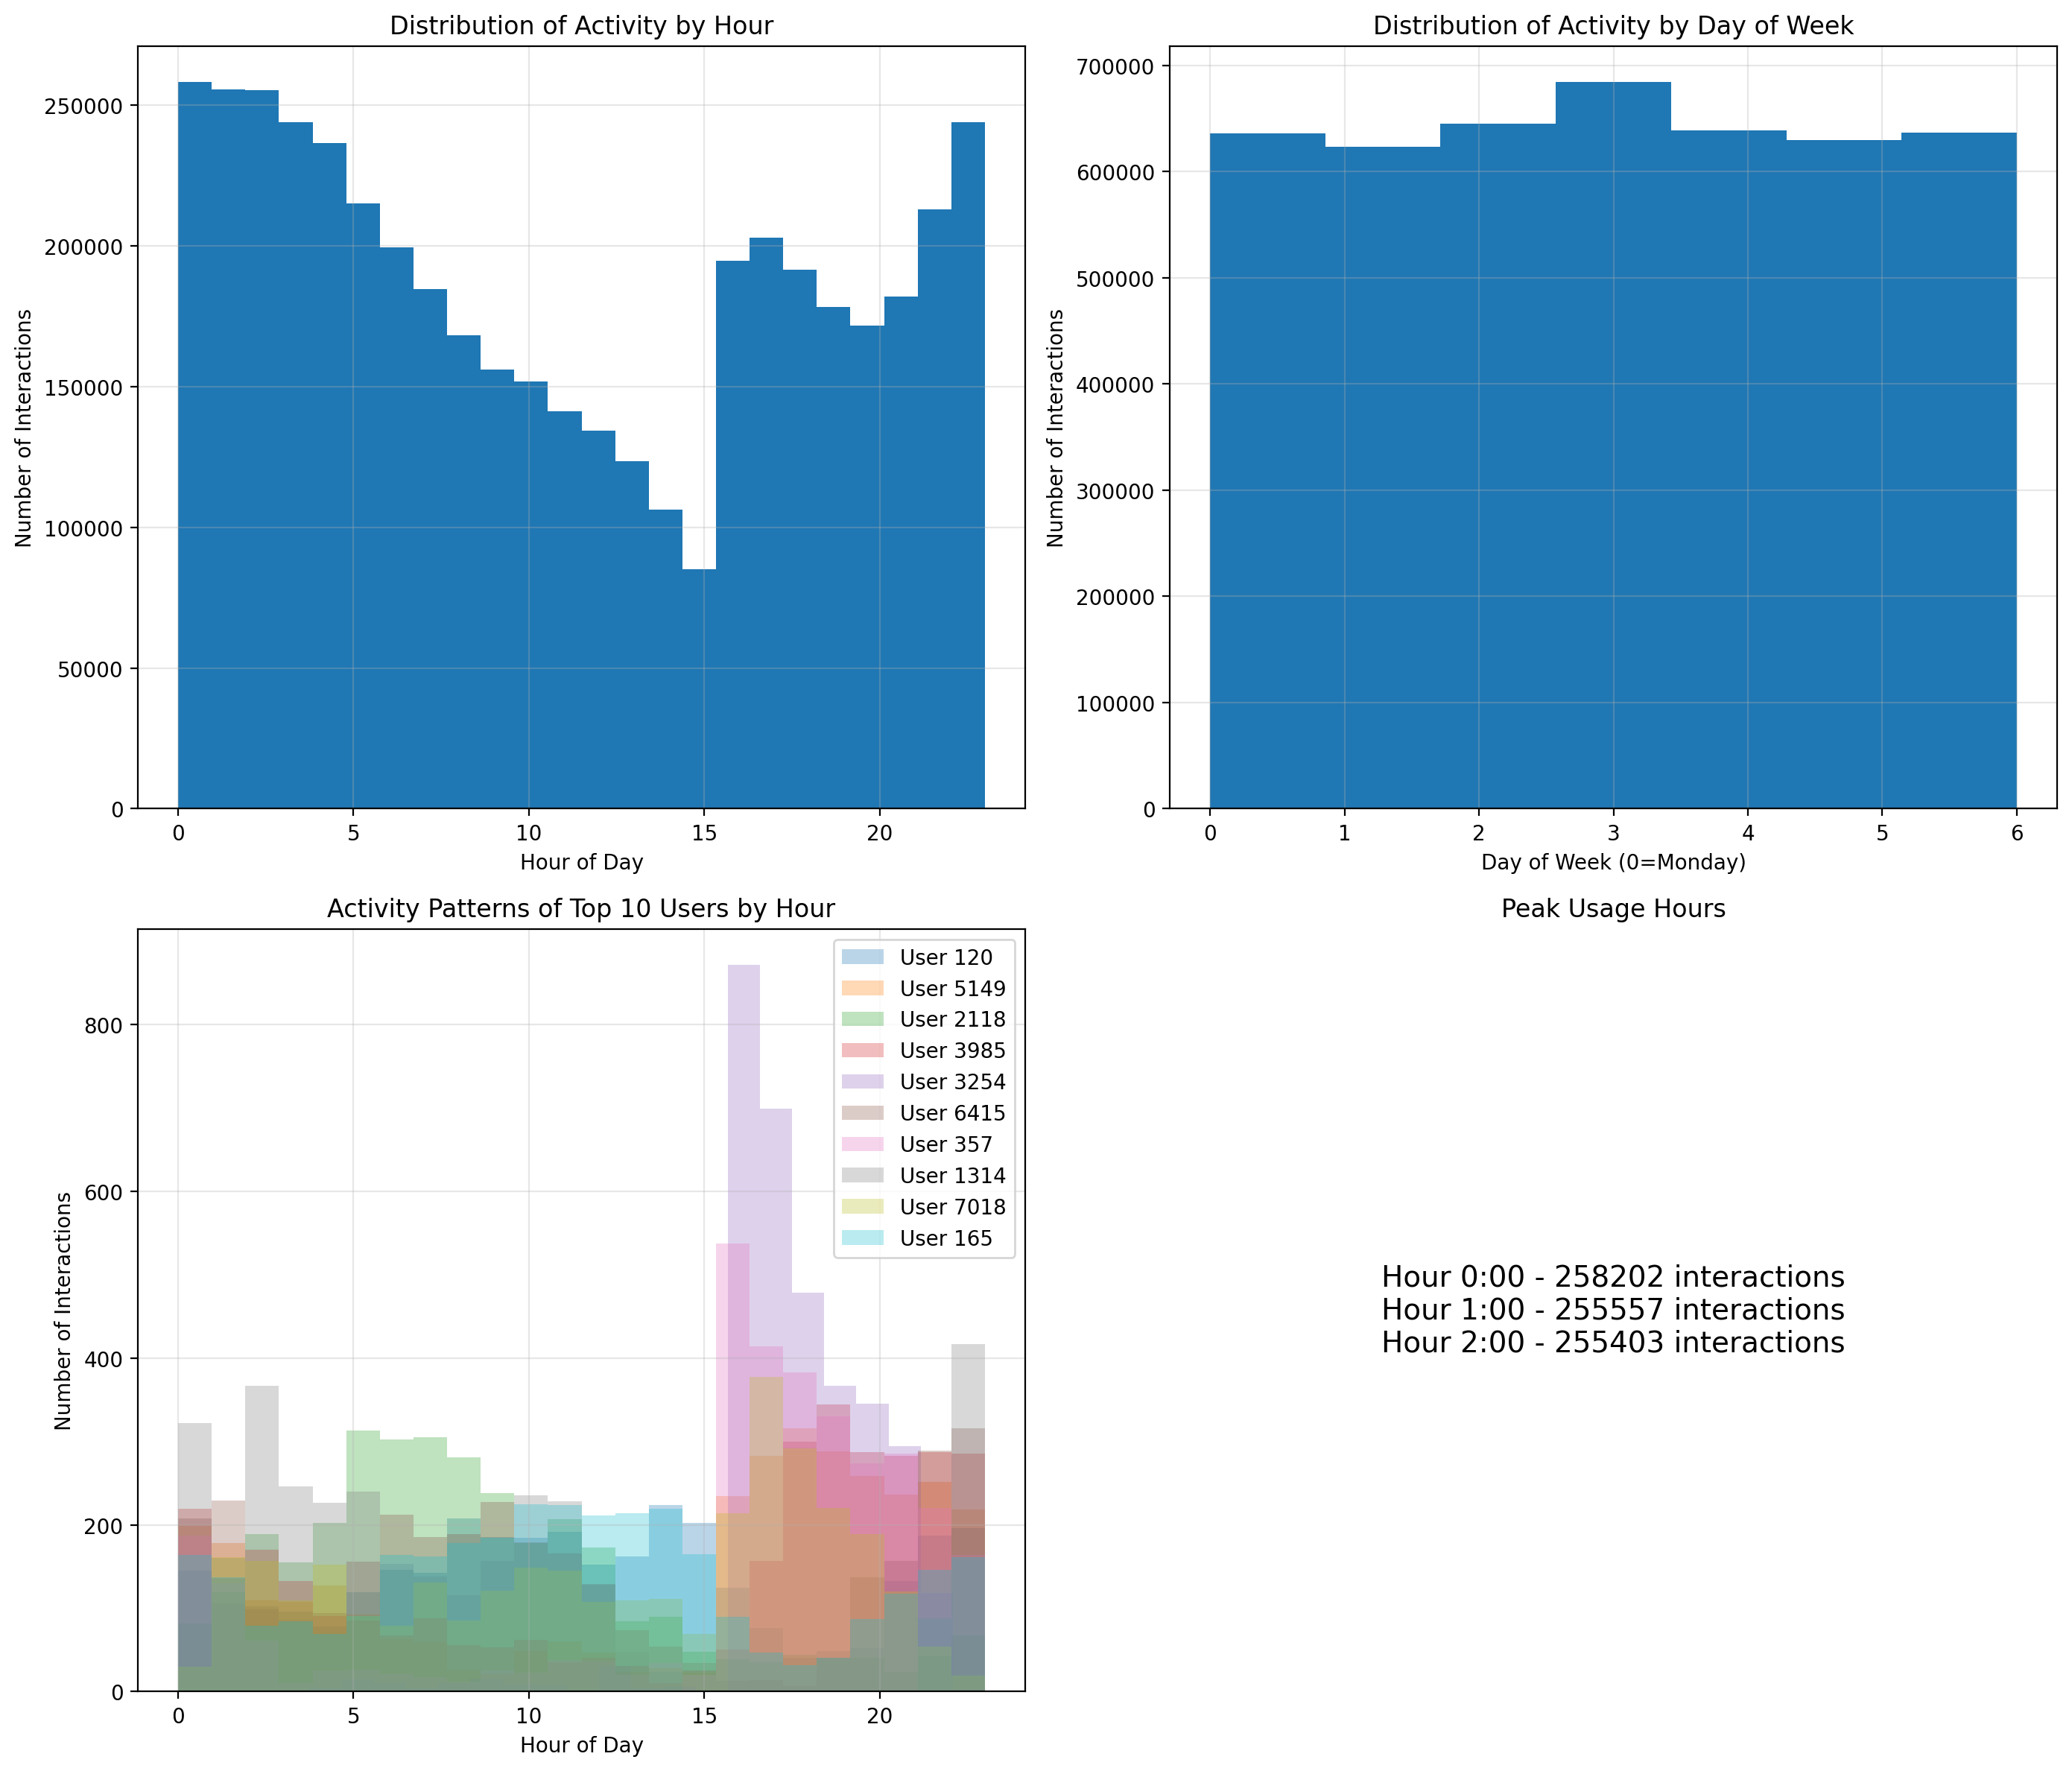

In [10]:
interactions["timestamp"] = pd.to_datetime(
    interactions["timestamp"].fillna(0), unit="s"
)

interactions["hour"] = interactions["timestamp"].dt.hour
interactions["day"] = interactions["timestamp"].dt.dayofweek

# Get top 10 most active users
top_users = interactions["user_id"].value_counts().head(10).index

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].hist(interactions["hour"], bins=24)
axes[0, 0].set_title("Distribution of Activity by Hour")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Number of Interactions")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(interactions["day"], bins=7)
axes[0, 1].set_title("Distribution of Activity by Day of Week")
axes[0, 1].set_xlabel("Day of Week (0=Monday)")
axes[0, 1].set_ylabel("Number of Interactions")
axes[0, 1].grid(True, alpha=0.3)

# Activity Patterns of Top 10 Users by Hour
for user in top_users:
    user_data = interactions[interactions["user_id"] == user]
    axes[1, 0].hist(user_data["hour"], bins=24, alpha=0.3, label=f"User {user}")
axes[1, 0].set_title("Activity Patterns of Top 10 Users by Hour")
axes[1, 0].set_xlabel("Hour of Day")
axes[1, 0].set_ylabel("Number of Interactions")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Peak Usage
hourly_activity = interactions.groupby("hour").size()
peak_hours = hourly_activity.nlargest(3)
peak_hours_str = "\n".join([f"Hour {hour}:00 - {count} interactions" for hour, count in peak_hours.items()])

axes[1, 1].text(0.5, 0.5, peak_hours_str, ha='center', va='center', fontsize=14)
axes[1, 1].set_title("Peak Usage Hours")
axes[1, 1].axis('off')  # Turn off the axis for text plot

# Adjust layout
plt.tight_layout()
plt.show()


#### Thinking 🤔
From the three graphs, we see that the number of interactions :
- Is at it peak **during the end of the week** (Friday through Sunday)
- Is at it peak **around 0:00 - 3:00 a.m.**

The ten most active users are not active around 12:00 and 16:00

---

<ins>We can also analyse :<ins>
- The watch ratio according to the duration of a video
- The watch ratio during different time of the week

/var/folders/pg/1l4d75p90r565jztmcw4v8c00000gn/T/ipykernel_24137/1830333468.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_watch_ratio_per_video_duration = interactions.groupby("video_duration_bin")["watch_ratio"].mean()


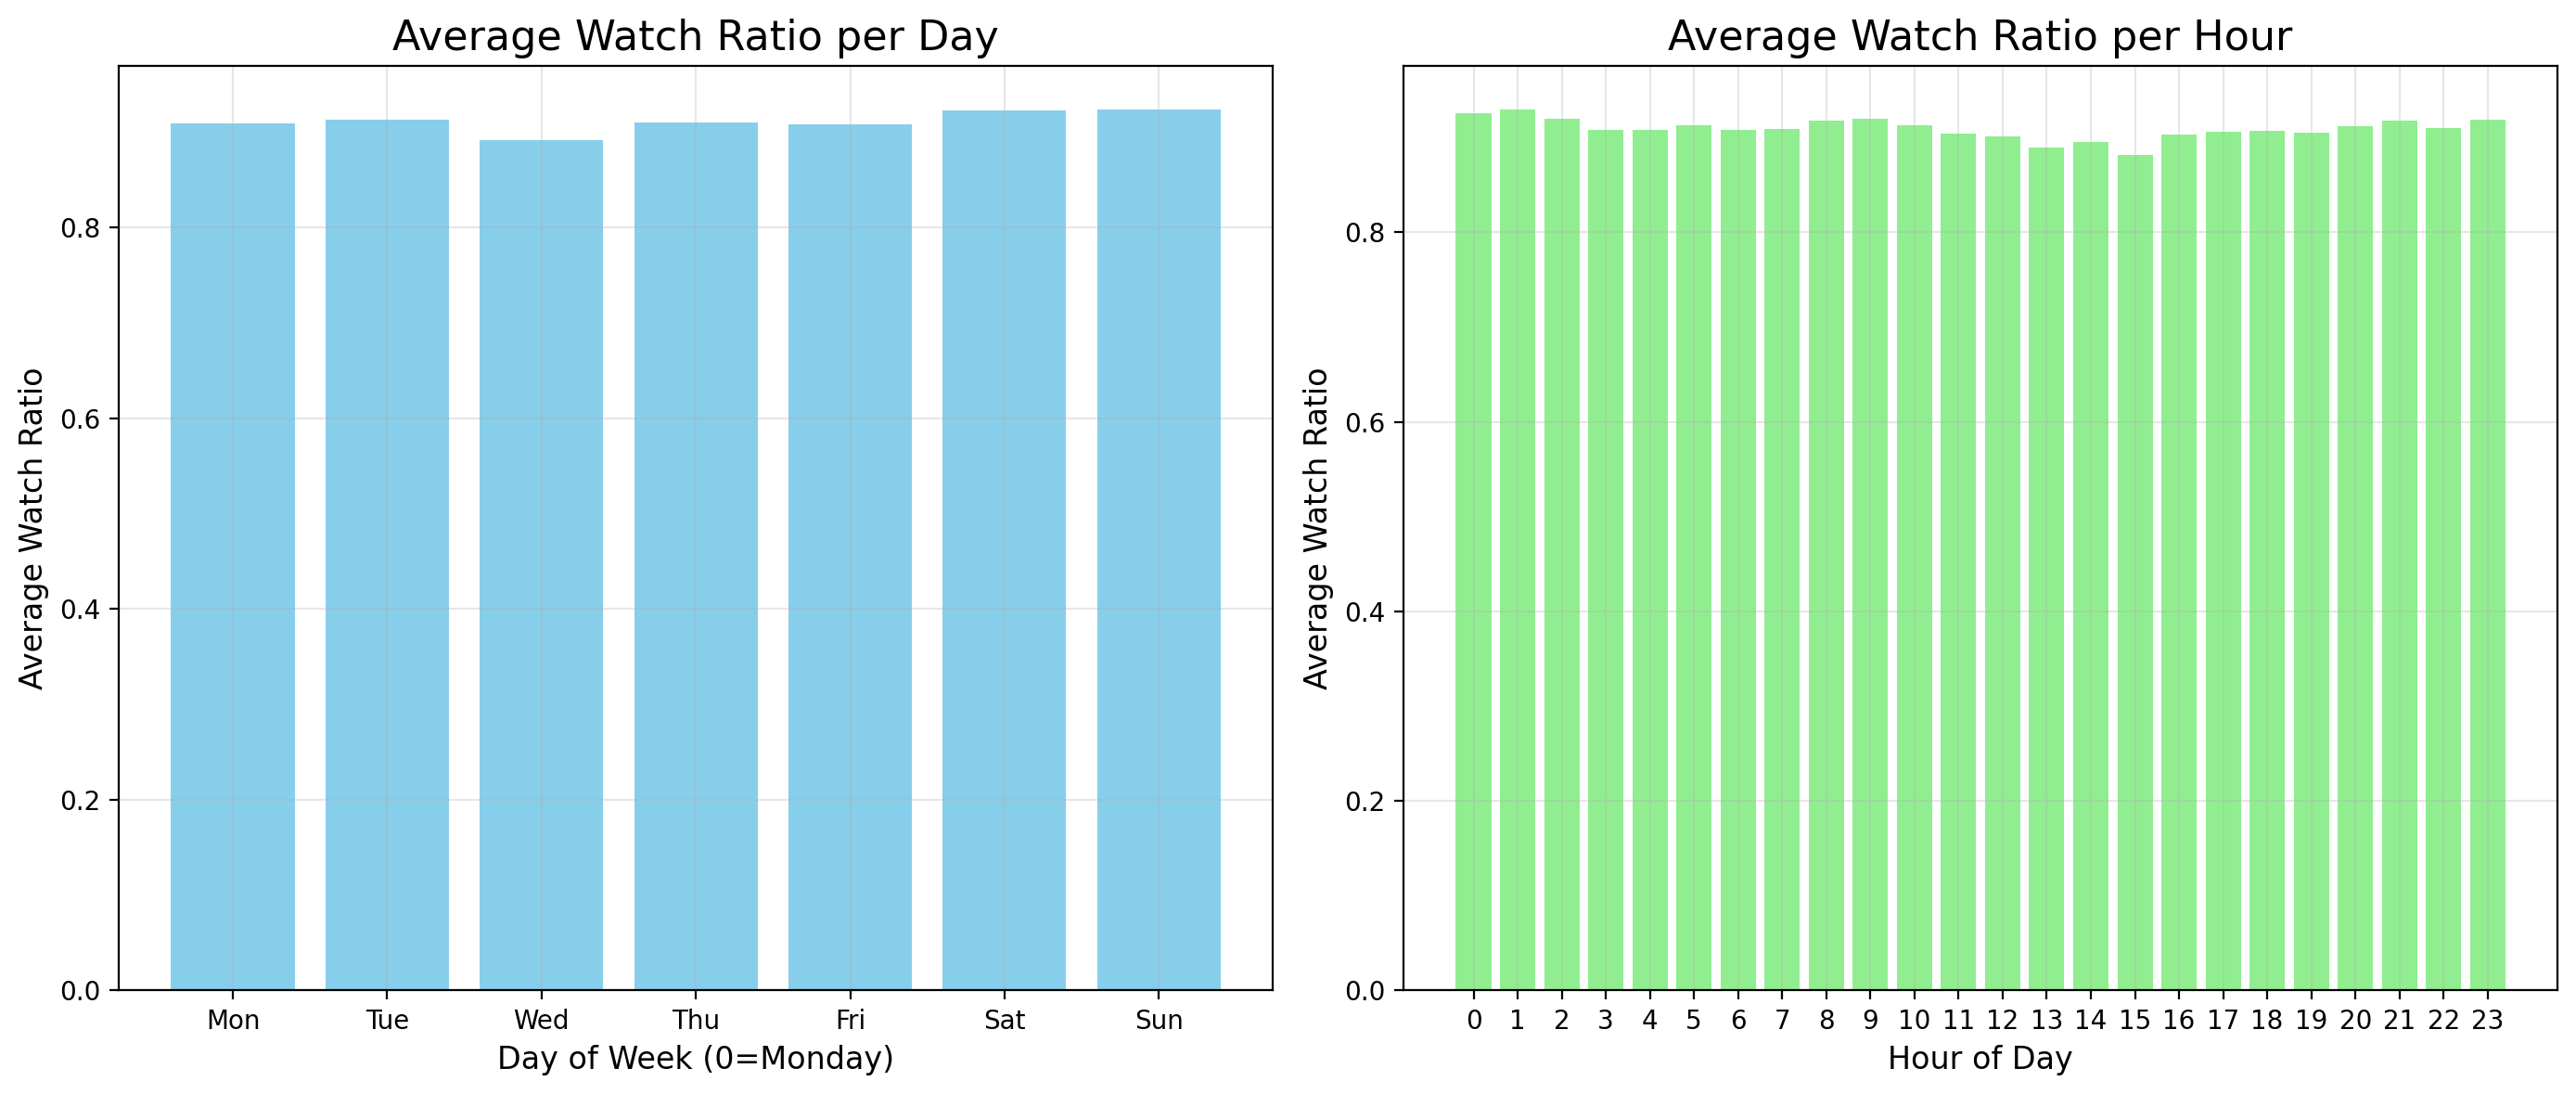

In [11]:
avg_watch_ratio_per_day = interactions.groupby("day")["watch_ratio"].mean()
avg_watch_ratio_per_hour = interactions.groupby("hour")["watch_ratio"].mean()

interactions["video_duration_sec"] = interactions["video_duration"] / 1000
video_duration_bins = [0, 30, 60, 120, 180, 300, 600, 1200, 3600, 7200, 14400]
interactions['video_duration_bin'] = pd.cut(interactions['video_duration_sec'], bins=video_duration_bins)
avg_watch_ratio_per_video_duration = interactions.groupby("video_duration_bin")["watch_ratio"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns

# 1. Average Watch Ratio per Day
axes[0].bar(avg_watch_ratio_per_day.index, avg_watch_ratio_per_day.values, color='skyblue')
axes[0].set_title("Average Watch Ratio per Day", fontsize=16)
axes[0].set_xlabel("Day of Week (0=Monday)", fontsize=12)
axes[0].set_ylabel("Average Watch Ratio", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# 2. Average Watch Ratio per Hour
axes[1].bar(avg_watch_ratio_per_hour.index, avg_watch_ratio_per_hour.values, color='lightgreen')
axes[1].set_title("Average Watch Ratio per Hour", fontsize=16)
axes[1].set_xlabel("Hour of Day", fontsize=12)
axes[1].set_ylabel("Average Watch Ratio", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


#### Thinking 🤔
<ins>From the 2 graphs above, we can deduce that :<ins>
> The time of the day or day of the week has no or small impact on the watch ratio. 

### 🥱 Link between interactions and video length

The question we want to answer here is, **does people usually enjoy longer or small videos ?**

/var/folders/pg/1l4d75p90r565jztmcw4v8c00000gn/T/ipykernel_24137/1796138651.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_watch_ratio_per_video_duration = interactions.groupby("video_duration_bin")["watch_ratio"].mean()


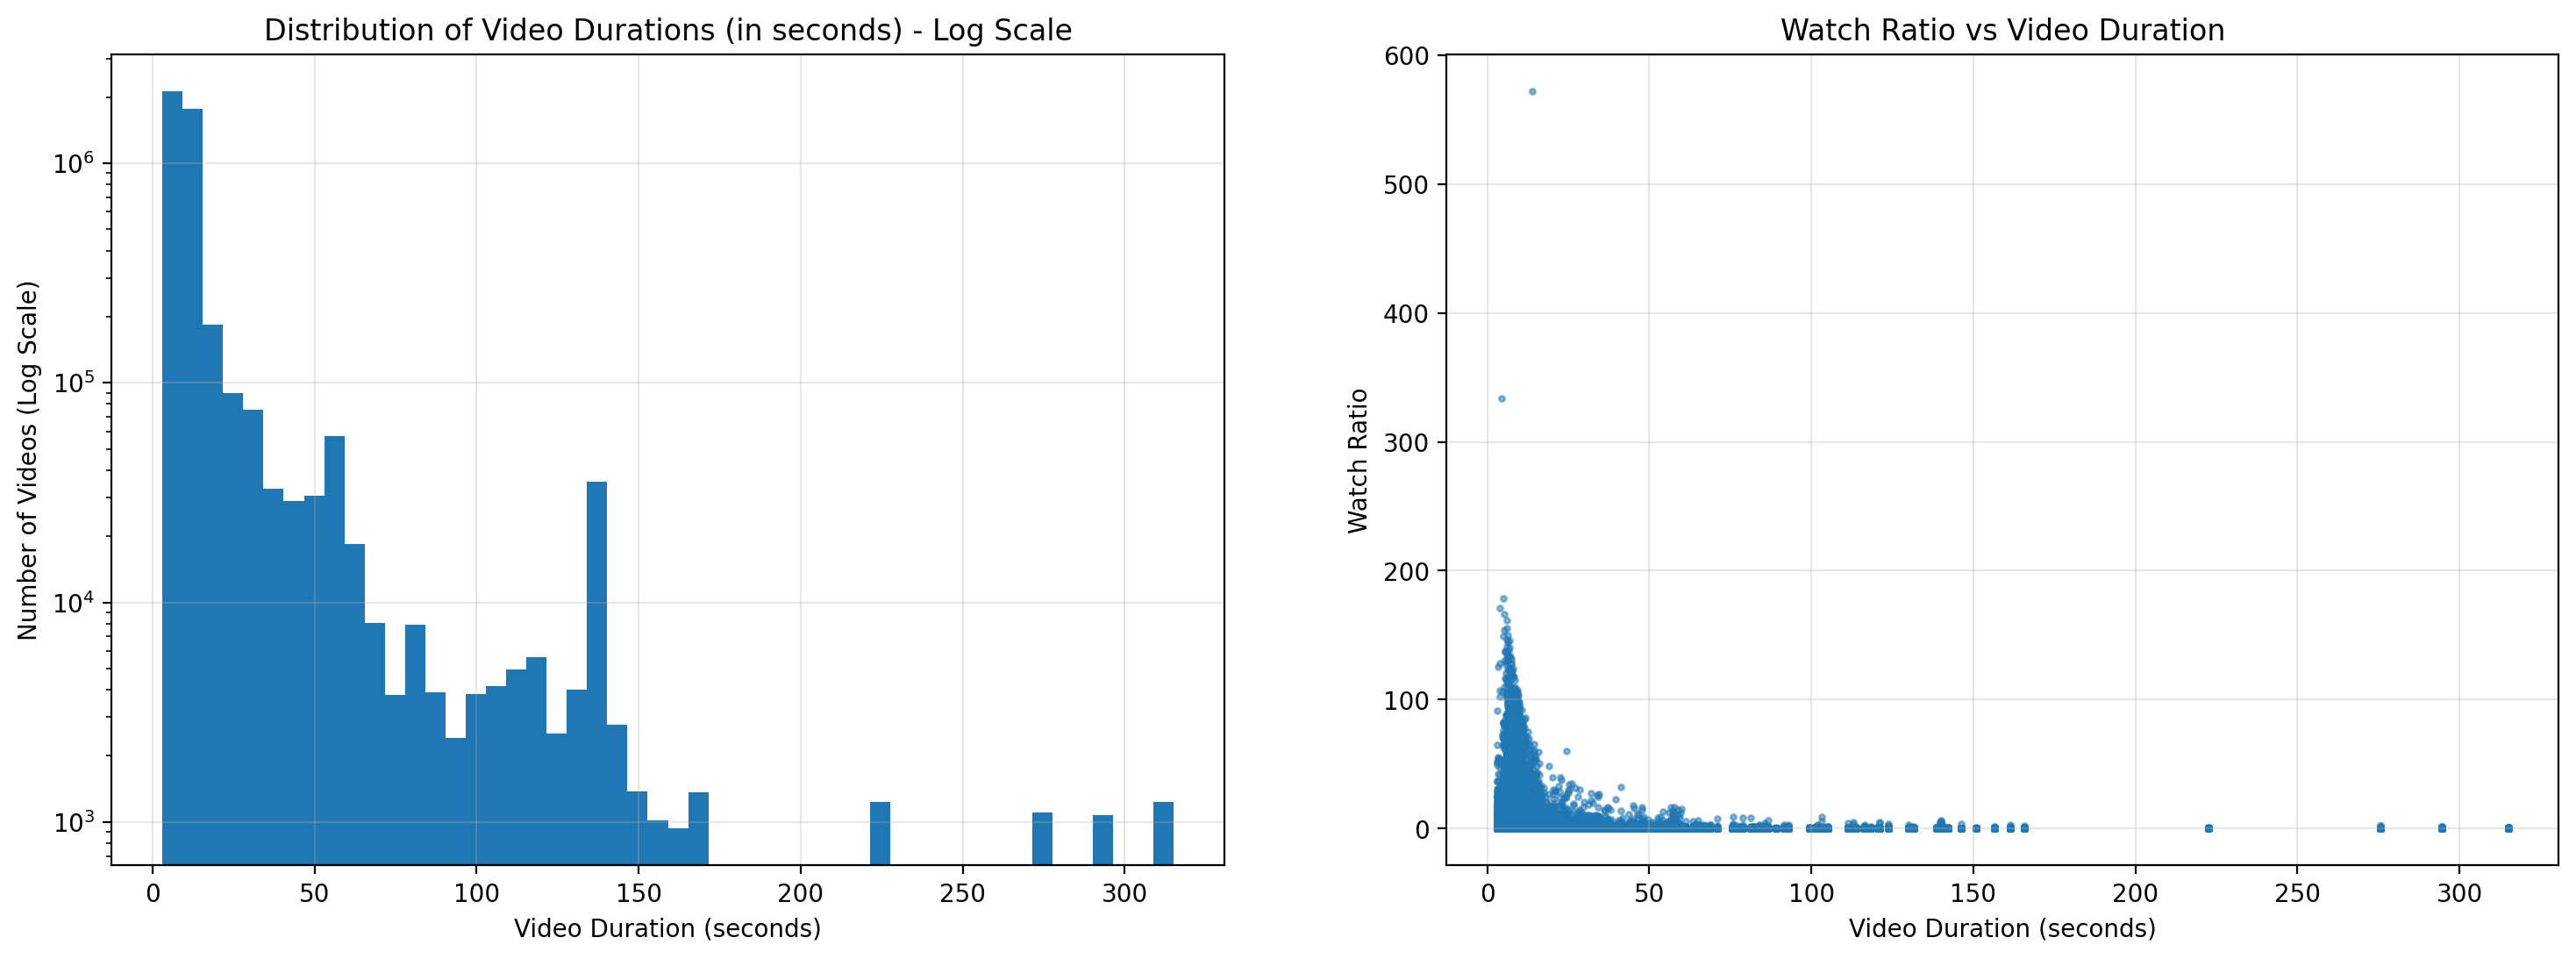

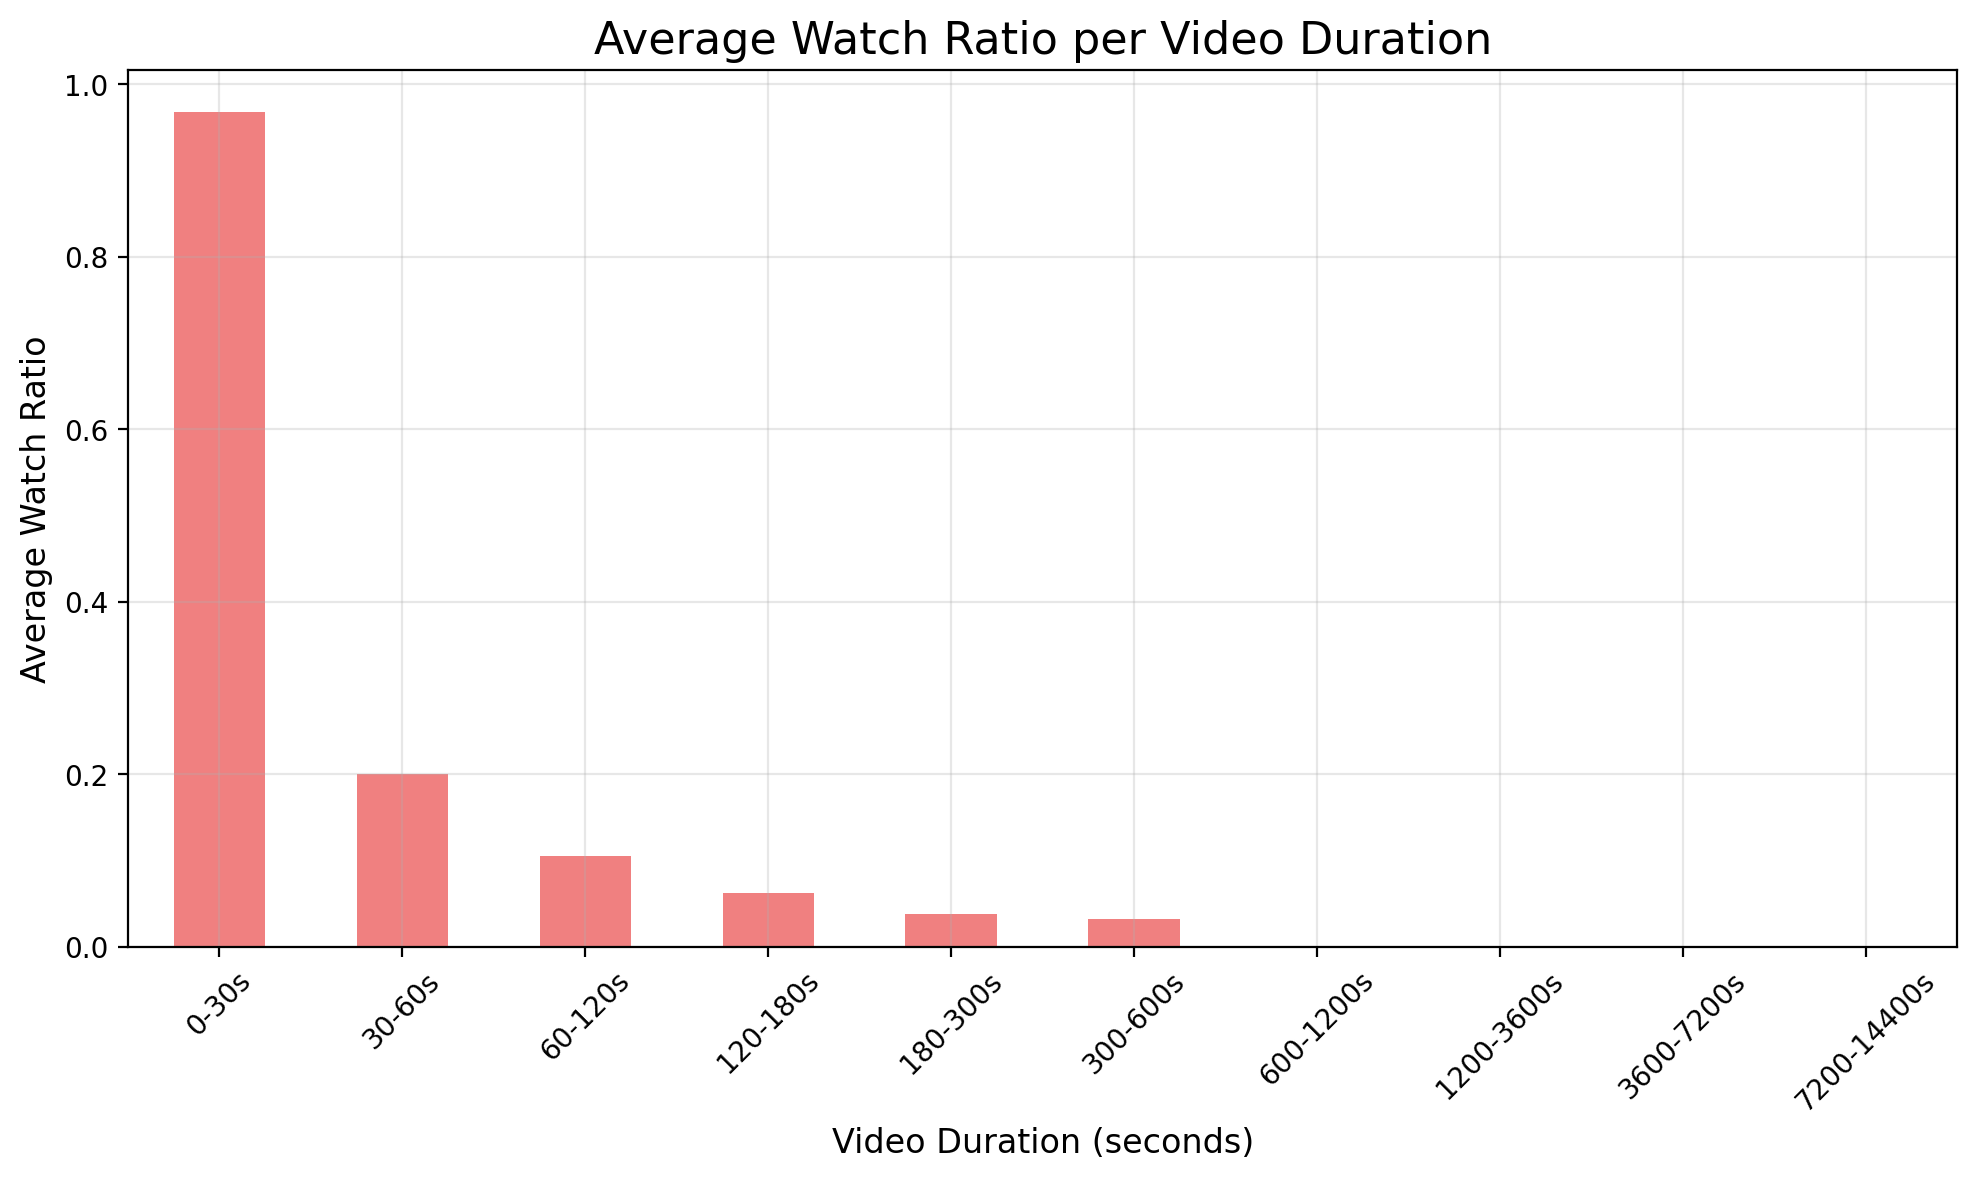

In [12]:
# milli to seconds
interactions["video_duration_sec"] = interactions["video_duration"] / 1000

# Prepare data for average watch ratio per video duration
video_duration_bins = [0, 30, 60, 120, 180, 300, 600, 1200, 3600, 7200, 14400]
interactions['video_duration_bin'] = pd.cut(interactions['video_duration_sec'], bins=video_duration_bins)
avg_watch_ratio_per_video_duration = interactions.groupby("video_duration_bin")["watch_ratio"].mean()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of Video Durations (in seconds)
ax[0].hist(interactions["video_duration_sec"], bins=50, log=True)
ax[0].set_title("Distribution of Video Durations (in seconds) - Log Scale")
ax[0].set_xlabel("Video Duration (seconds)")
ax[0].set_ylabel("Number of Videos (Log Scale)")
ax[0].grid(True, alpha=0.3)

# 2. Watch Ratio vs Video Duration
ax[1].scatter(interactions["video_duration_sec"], interactions["watch_ratio"], alpha=0.5, s=5)
ax[1].set_title("Watch Ratio vs Video Duration")
ax[1].set_xlabel("Video Duration (seconds)")
ax[1].set_ylabel("Watch Ratio")
ax[1].grid(True, alpha=0.3)

# Create a new subplot for the average watch ratio per video duration
fig2, ax2 = plt.subplots(figsize=(10, 6))
avg_watch_ratio_per_video_duration.plot(kind="bar", color='lightcoral', ax=ax2)
ax2.set_title("Average Watch Ratio per Video Duration", fontsize=16)
ax2.set_xlabel("Video Duration (seconds)", fontsize=12)
ax2.set_ylabel("Average Watch Ratio", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels([f"{int(interval.left)}-{int(interval.right)}s" for interval in avg_watch_ratio_per_video_duration.index], rotation=45)

# Show the plots
plt.tight_layout()
plt.show()


#### Thinking 🤔
<ins>We clearly see that **shorter videos** have :<ins>
- **More interactions**
- **A higher watch ratio**

The optimal watch ratio appears to be for videos that are no longer than **30 seconds**.
Longer videos tend to see less interactions and watch ratio.

## 📝  Observations from the Data

- **User Interactions**: 
  - The majority of users have **fewer than 3,000 interactions**.
  - There are a few **outliers** with interactions exceeding 6,000.

- **Item Popularity**:
  - There are very few items that receive **high levels of interaction**.
  - Many items, while not extremely popular, still receive a fair amount of attention.
  - A small subset of items are truly **highly popular**.

- **Time-Based Trends**:
  - However, interactions peak towards the **end of the week**, specifically from **Friday to Sunday**.
  - **Late-night hours (0:00 - 3:00 a.m.)** see the highest levels of activity.
  - **From 10:00 to 20:00** we see less activity
  - The time of day or day of the week has **minimal to no impact** on the watch ratio.

- **User Behavior**:
  - The **top 10 most active users** show a distinct dip in activity around **12:00 p.m.** and **4:00 p.m.**.

- **Video Length**:
  - **Shorter videos** (up to 30 seconds) receive **more interactions** and have a **higher watch ratio**.
  - Conversely, **longer videos** tend to have **fewer interactions** and a lower watch ratio.
  - Videos that are **no longer than 30 seconds** appear to have the optimal watch ratio.

# **2️⃣ Exploratory Data Analysis - Items**
🔍 For this data analysis, we will focus on the **item Features**, i.e., the data that contains the items different features

## 💎 Data Preprocessing

In [34]:
item_features = pd.read_csv("../data_final_project/KuaiRec/data/item_daily_features.csv")
item_features.head()

,video_id,date,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,video_width,video_height,...,download_cnt,download_user_num,report_cnt,report_user_num,reduce_similar_cnt,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num
0,0,20200705,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,8,8,0,0,3,3,NaN,NaN,NaN,NaN
1,0,20200706,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,5,5,NaN,NaN,NaN,NaN
2,0,20200707,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,0,0,NaN,NaN,NaN,NaN
3,0,20200708,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,3,3,0,0,3,3,NaN,NaN,NaN,NaN
4,0,20200709,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,2,1,1,1,NaN,NaN,NaN,NaN


In [ ]:
item_features['upload_dt'] = pd.to_datetime(item_features['upload_dt'])
item_features['date'] = pd.to_datetime(item_features['date'], format='%Y%m%d')

```Description of the columns present in the dataset :```
| Field Name                | Description                                      | Type   | Example                                                                 |
|---------------------------|--------------------------------------------------|--------|-------------------------------------------------------------------------|
| video_id                  | The ID of the video.                             | int64  | 3784                                                                  |
| date                      | Date of the statistics of this video.           | int64  | 20200730                                                              |
| author_id                 | The ID of the author of this video.            | int64  | 441                                                                   |
| video_type                | Type of this video (NORMAL or AD).             | str    | "NORMAL"                                                              |
| upload_dt                | Upload date of this video.                     | str    | "2020-07-08"                                                         |
| upload_type              | The upload type of this video.                 | str    | "ShortImport"                                                         |
| visible_status           | The visible state of this video on the APP now.| str    | "public"                                                               |
| video_duration           | The time duration of this video (in milliseconds). | float64| 17200.0                                                             |
| video_width              | The width of this video on the server.         | int64  | 720                                                                   |
| video_height             | The height of this video on the server.        | int64  | 1280                                                                  |
| music_id                 | Background music ID of this video.            | int64  | 989206467                                                             |
| video_tag_id             | The ID of the tag of this video.              | int64  | 2522                                                                  |
| video_tag_name           | The name of the tag of this video.            | string | "祝福"                                                                 |
| show_cnt                 | The number of shows of this video within this day. | int64  | 7716                                                                  |
| show_user_num            | The number of users who received the recommendation of this video. | int64  | 5256                                                                  |
| play_cnt                  | The number of plays.                           | int64  | 7701                                                                  |
| play_user_num             | The number of users who play this video.       | int64  | 5034                                                                  |
| play_duration            | The total time duration of playing this video (in milliseconds). | int64  | 138333346                                                            |
| complete_play_cnt         | The number of complete plays. complete play: finishing playing the whole video, i.e., #(play_duration >= video_duration). | int64  | 3446                                                                 |
| complete_play_user_num    | The number of users who perform the complete play. | int64  | 2033                                                                  |
| valid_play_cnt            | Valid play: play_duration >= video_duration if video_duration <= 7s, or play_duration > 7 if video_duration > 7s. | int64  | 5099                                                                 |
| valid_play_user_num       | The number of users who perform the complete play. | int64  | 3195                                                                  |
| long_time_play_cnt        | Long time play: play_duration >= video_duration if video_duration <= 18s, or play_duration >=18 if video_duration > 18s. | int64  | 3299                                                                 |
| long_time_play_user_num    | The number of users who perform the long time play. | int64  | 1940                                                                  |
| short_time_play_cnt       | Short time play: play_duration < min(3s, video_duration). | int64  | 1538                                                                  |
| short_time_play_user_num   | The number of users who perform the short time play. | int64  | 1190                                                                  |
| play_progress             | The average video playing ratio (=play_duration/video_duration) | int64  | 0.579695                                                              |
| comment_stay_duration     | Total time of staying in the comments section  | int64  | 467865                                                                 |
| like_cnt                  | Total likes                                   | int64  | 659                                                                   |
| like_user_num             | The number of users who hit the “like” button. | int64  | 657                                                                   |
| click_like_cnt            | The number of the “like” resulted from double click | int64  | 496                                                                   |
| double_click_cnt          | The number of users who double-click the video.| int64  | 163                                                                    |
| cancel_like_cnt           | The number of likes that are canceled by users.| int64  | 15                                                                    |
| cancel_like_user_num      | The number of users who cancel their likes.   | int64  | 15                                                                    |
| comment_cnt               | The number of comments within this day.       | int64  | 13                                                                    |
| comment_user_num          | The number of users who comment on this video. | int64  | 12                                                                    |
| direct_comment_cnt        | The number of direct comments (depth=1).        | int64  | 13                                                                    |
| reply_comment_cnt         | The number of reply comments (depth>1).         | int64  | 0                                                                      |
| delete_comment_cnt        | The number of deleted comments.               | int64  | 0                                                                      |
| delete_comment_user_num    | The number of users who delete their comments.| int64  | 0                                                                      |
| comment_like_cnt          | The number of comment likes.                  | int64  | 2                                                                      |
| comment_like_user_num     | The number of users who like the comments.    | int64  | 2                                                                      |
| follow_cnt                | The number of increased follows from this video.| int64  | 151                                                                    |
| follow_user_num           | The number of users who follow the author of this video due to this video. | int64  | 151                                                                   |
| cancel_follow_cnt         | The number of decreased follows from this video.| int64  | 0                                                                      |
| cancel_follow_user_num     | The number of users who cancel their following of the author of this video due to this video. | int64  | 0                                                                      |
| share_cnt                 | The times of sharing this video.              | int64  | 1                                                                      |
| share_user_num            | The number of users who share this video.     | int64  | 1                                                                      |
| download_cnt              | The times of downloading this video.          | int64  | 2                                                                      |
| download_user_num         | The number of users who download this video.  | int64  | 2                                                                      |
| report_cnt                | The times of reporting this video.            | int64  | 0                                                                      |
| report_user_num           | The number of users who report this video.   | int64  | 0                                                                      |
| reduce_similar_cnt        | The times of reducing similar content of this video. | int64  | 2                                                                      |
| reduce_similar_user_num    | The number of users who choose to reduce similar content of this video. | int64  | 2                                                                      |
| collect_cnt               | The times of adding this video to favorite videos. | int64  | 0                                                                      |
| collect_user_num          | The number of users who add this video to their favorite videos. | int64  | 0                                                                      |
| cancel_collect_cnt        | The times of removing this video from favorite videos. | int64  | 0                                                                      |
| cancel_collect_user_num    | The number of users who remove this video from their favorite videos | int64  | 0                                                                      |


## ❓Basic Questions

In [14]:
item_features.columns

Index(['video_id', 'date', 'author_id', 'video_type', 'upload_dt',
       'upload_type', 'visible_status', 'video_duration', 'video_width',
       'video_height', 'music_id', 'video_tag_id', 'video_tag_name',
       'show_cnt', 'show_user_num', 'play_cnt', 'play_user_num',
       'play_duration', 'complete_play_cnt', 'complete_play_user_num',
       'valid_play_cnt', 'valid_play_user_num', 'long_time_play_cnt',
       'long_time_play_user_num', 'short_time_play_cnt',
       'short_time_play_user_num', 'play_progress', 'comment_stay_duration',
       'like_cnt', 'like_user_num', 'click_like_cnt', 'double_click_cnt',
       'cancel_like_cnt', 'cancel_like_user_num', 'comment_cnt',
       'comment_user_num', 'direct_comment_cnt', 'reply_comment_cnt',
       'delete_comment_cnt', 'delete_comment_user_num', 'comment_like_cnt',
       'comment_like_user_num', 'follow_cnt', 'follow_user_num',
       'cancel_follow_cnt', 'cancel_follow_user_num', 'share_cnt',
       'share_user_num', 'download

In [35]:
print("Columns that have high correlation with another column")
correlation = item_features[[
       'video_duration', 'video_width',
       'video_height', 'music_id',
       'show_cnt', 'show_user_num', 'play_cnt', 'play_user_num',
       'play_duration', 'complete_play_cnt', 'complete_play_user_num',
       'valid_play_cnt', 'valid_play_user_num', 'long_time_play_cnt',
       'long_time_play_user_num', 'short_time_play_cnt',
       'short_time_play_user_num', 'play_progress', 'comment_stay_duration',
       'like_cnt', 'like_user_num', 'click_like_cnt', 'double_click_cnt',
       'cancel_like_cnt', 'cancel_like_user_num', 'comment_cnt',
       'comment_user_num', 'direct_comment_cnt', 'reply_comment_cnt',
       'delete_comment_cnt', 'delete_comment_user_num', 'comment_like_cnt',
       'comment_like_user_num', 'follow_cnt', 'follow_user_num',
       'cancel_follow_cnt', 'cancel_follow_user_num', 'share_cnt',
       'share_user_num', 'download_cnt', 'download_user_num', 'report_cnt',
       'report_user_num', 'reduce_similar_cnt', 'reduce_similar_user_num',
       'collect_cnt', 'collect_user_num', 'cancel_collect_cnt',
       'cancel_collect_user_num']].corr()

upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))


to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print(to_drop)


Columns that have high correlation with another column
['show_user_num', 'play_cnt', 'play_user_num', 'play_duration', 'complete_play_cnt', 'complete_play_user_num', 'valid_play_cnt', 'valid_play_user_num', 'long_time_play_cnt', 'long_time_play_user_num', 'short_time_play_cnt', 'short_time_play_user_num', 'like_cnt', 'like_user_num', 'click_like_cnt', 'double_click_cnt', 'cancel_like_user_num', 'comment_user_num', 'direct_comment_cnt', 'delete_comment_user_num', 'comment_like_user_num', 'follow_user_num', 'cancel_follow_user_num', 'share_user_num', 'download_user_num', 'report_user_num', 'reduce_similar_cnt', 'reduce_similar_user_num', 'collect_cnt', 'collect_user_num', 'cancel_collect_user_num']


In [36]:
item_features.drop(columns=to_drop, inplace=True, errors='ignore')

item_features.head()

,video_id,date,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,video_width,video_height,...,comment_cnt,reply_comment_cnt,delete_comment_cnt,comment_like_cnt,follow_cnt,cancel_follow_cnt,share_cnt,download_cnt,report_cnt,cancel_collect_cnt
0,0,20200705,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,11,3,0,112,284,0,2,8,0,NaN
1,0,20200706,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,7,1,0,60,201,0,1,2,0,NaN
2,0,20200707,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,4,1,0,59,131,0,1,2,0,NaN
3,0,20200708,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,4,2,0,91,179,0,2,3,0,NaN
4,0,20200709,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,5,5,0,76,186,0,0,2,2,NaN


In [37]:
print("Different video types ?")
print(item_features["video_type"].unique())

print("Different Status ?")
print(item_features["visible_status"].unique())

print("Different uploads ?")
print(item_features["upload_type"].unique())

Different video types ?
['NORMAL' 'AD']
Different Status ?
['public' 'private' 'only friends']
Different uploads ?
['ShortImport' 'PictureSet' 'Kmovie' 'ShortCamera' 'LongImport'
 'LongCamera' 'FollowShoot' 'LongPicture' 'Web' 'UNKNOWN' 'FlashPhoto'
 'AiCutVideo' 'ShareFromOtherApp' 'PhotoCopy' 'LocalCollection'
 'SameFrame' 'PictureCopy' 'LocalIntelligenceAlbum']


In [45]:
print("What is the date range for the upload and the date ?")

print(item_features['date'].min(), item_features['date'].max())
print(item_features['upload_dt'].min(), item_features['upload_dt'].max())

What is the date range for the upload and the date ?
2020-07-05 00:00:00 2020-09-05 00:00:00
2019-05-18 00:00:00 2020-09-05 00:00:00


## 📊 Basic Statistics & Distributions

### 🎥 Type of videos and interactions

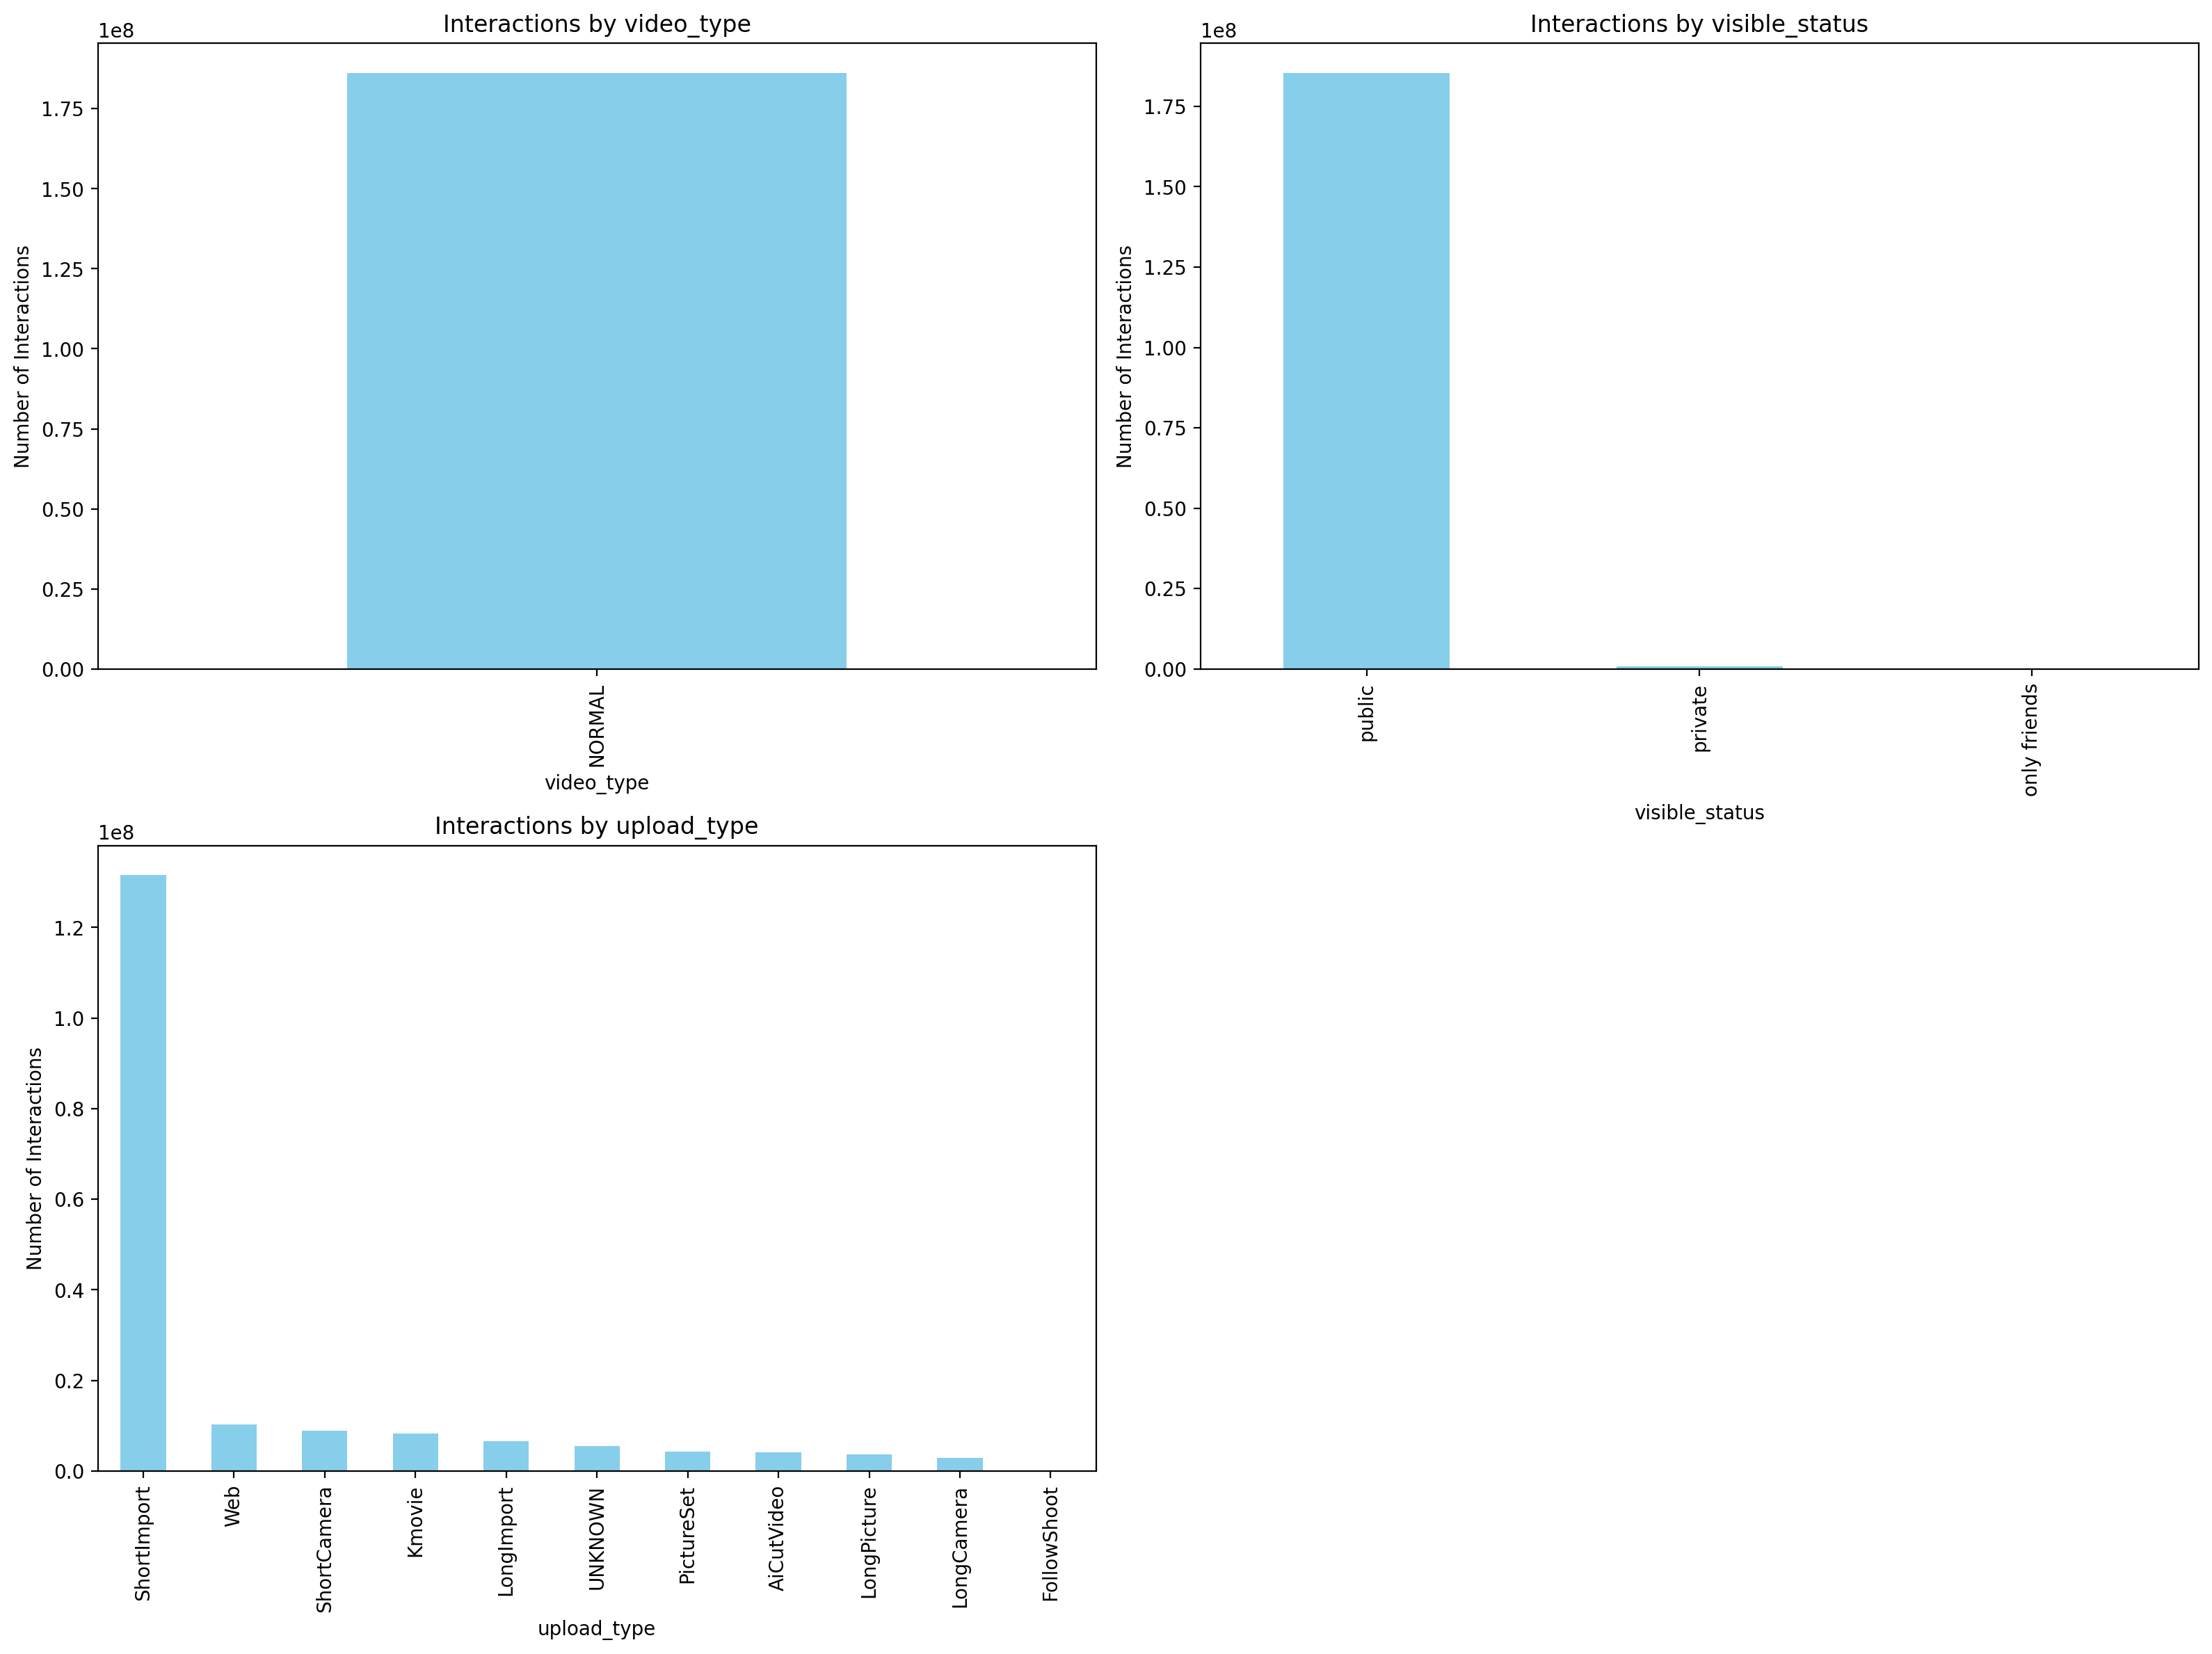

In [38]:
columns_to_keep = ['video_type', 'visible_status', 'upload_type']
studied_features = item_features[columns_to_keep + ['video_id']]
item_interactions = pd.merge(interactions, studied_features, on='video_id', how='left')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(columns_to_keep):
    interaction_counts = item_interactions[col].value_counts()
    interaction_counts.plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Interactions by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Interactions')

fig.delaxes(axes[3])

plt.tight_layout()
plt.show()


#### Thinking 🤔
<ins>From the 3 graphs above, we cleary see that :<ins>
- Video of **type "Ad"** are less interacted with (contrary to `Normal`)
- Users have a preference for `Short Imports` over all the other upload type
- It is also good to mention, even though pretty trivial, that `public` video are more interacted with then `private` or `only friends` videos as there are way more public video that are published.

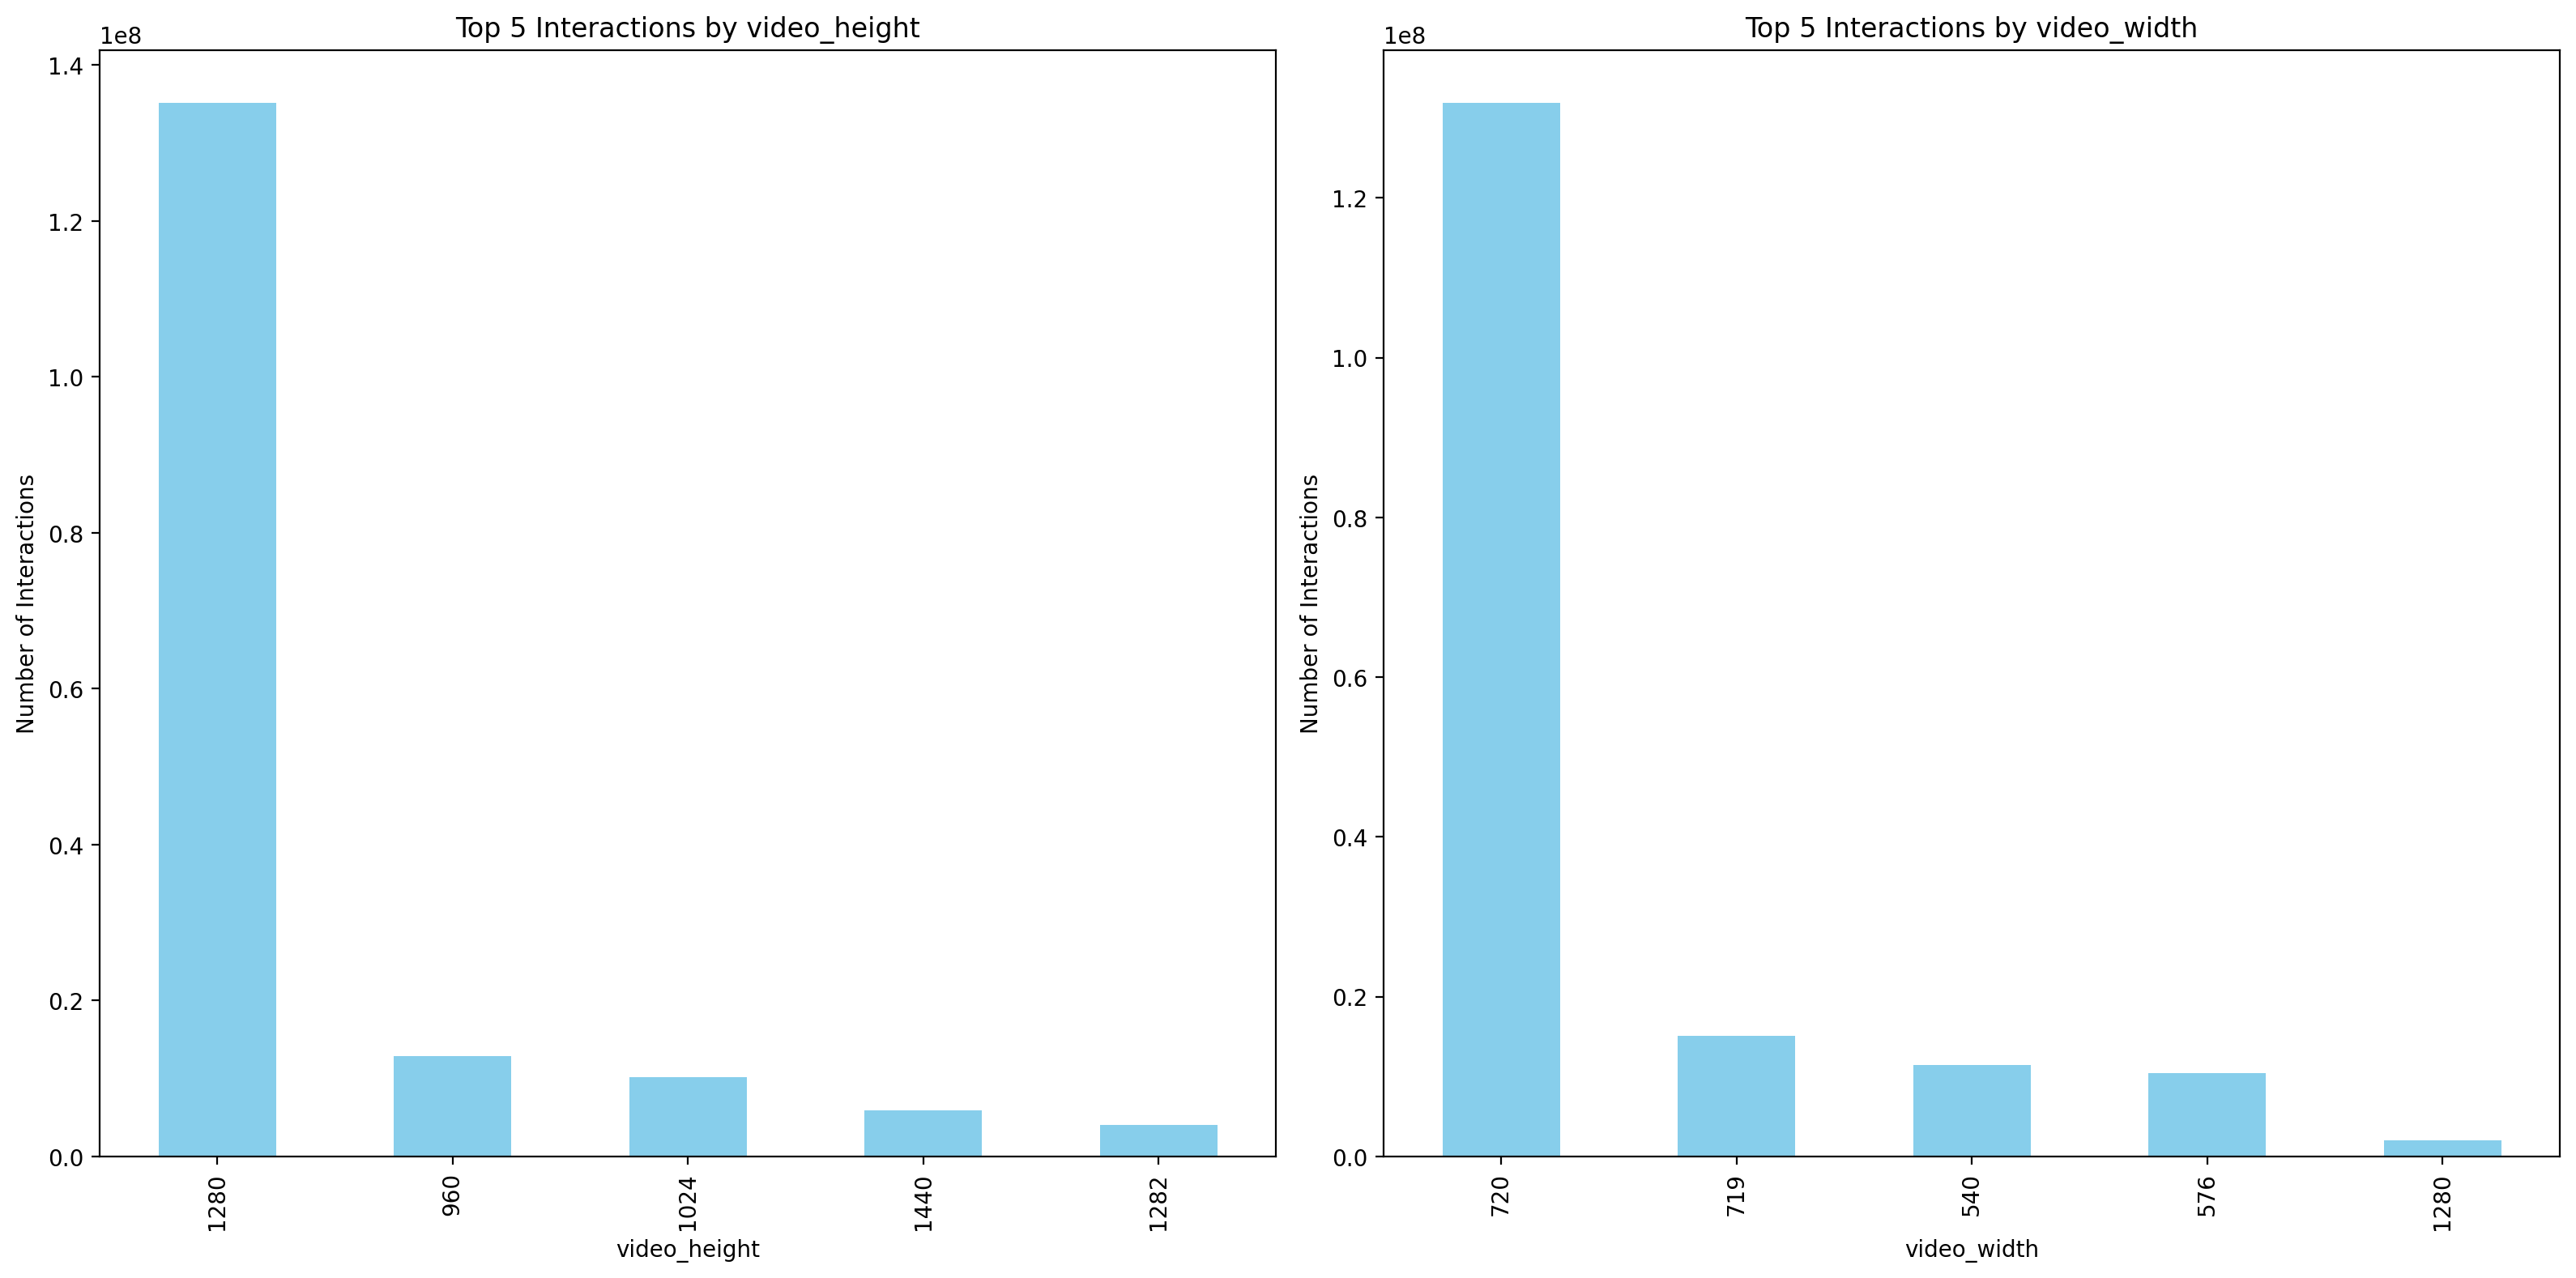

In [19]:
columns_to_keep = ['video_height', 'video_width']
studied_features = item_features[['video_id'] + columns_to_keep]  # Keep 'video_id' for merge
item_interactions = pd.merge(interactions, studied_features, on='video_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(columns_to_keep):
    interaction_counts = item_interactions[col].value_counts().nlargest(5)  # Get top 5
    interaction_counts.plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Top 5 Interactions by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Interactions')

plt.tight_layout()
plt.show()


#### Thinking 🤔
<ins>From the 2 graphs above, we cleary see that :<ins>
- The best video format is `1280x720`

In [29]:
item_features.columns

Index(['video_id', 'date', 'author_id', 'video_type', 'upload_dt',
       'upload_type', 'visible_status', 'video_duration', 'video_width',
       'video_height', 'music_id', 'video_tag_id', 'video_tag_name',
       'show_cnt', 'play_progress', 'comment_stay_duration', 'cancel_like_cnt',
       'comment_cnt', 'reply_comment_cnt', 'delete_comment_cnt',
       'comment_like_cnt', 'follow_cnt', 'cancel_follow_cnt', 'share_cnt',
       'download_cnt', 'report_cnt', 'cancel_collect_cnt'],
      dtype='object')

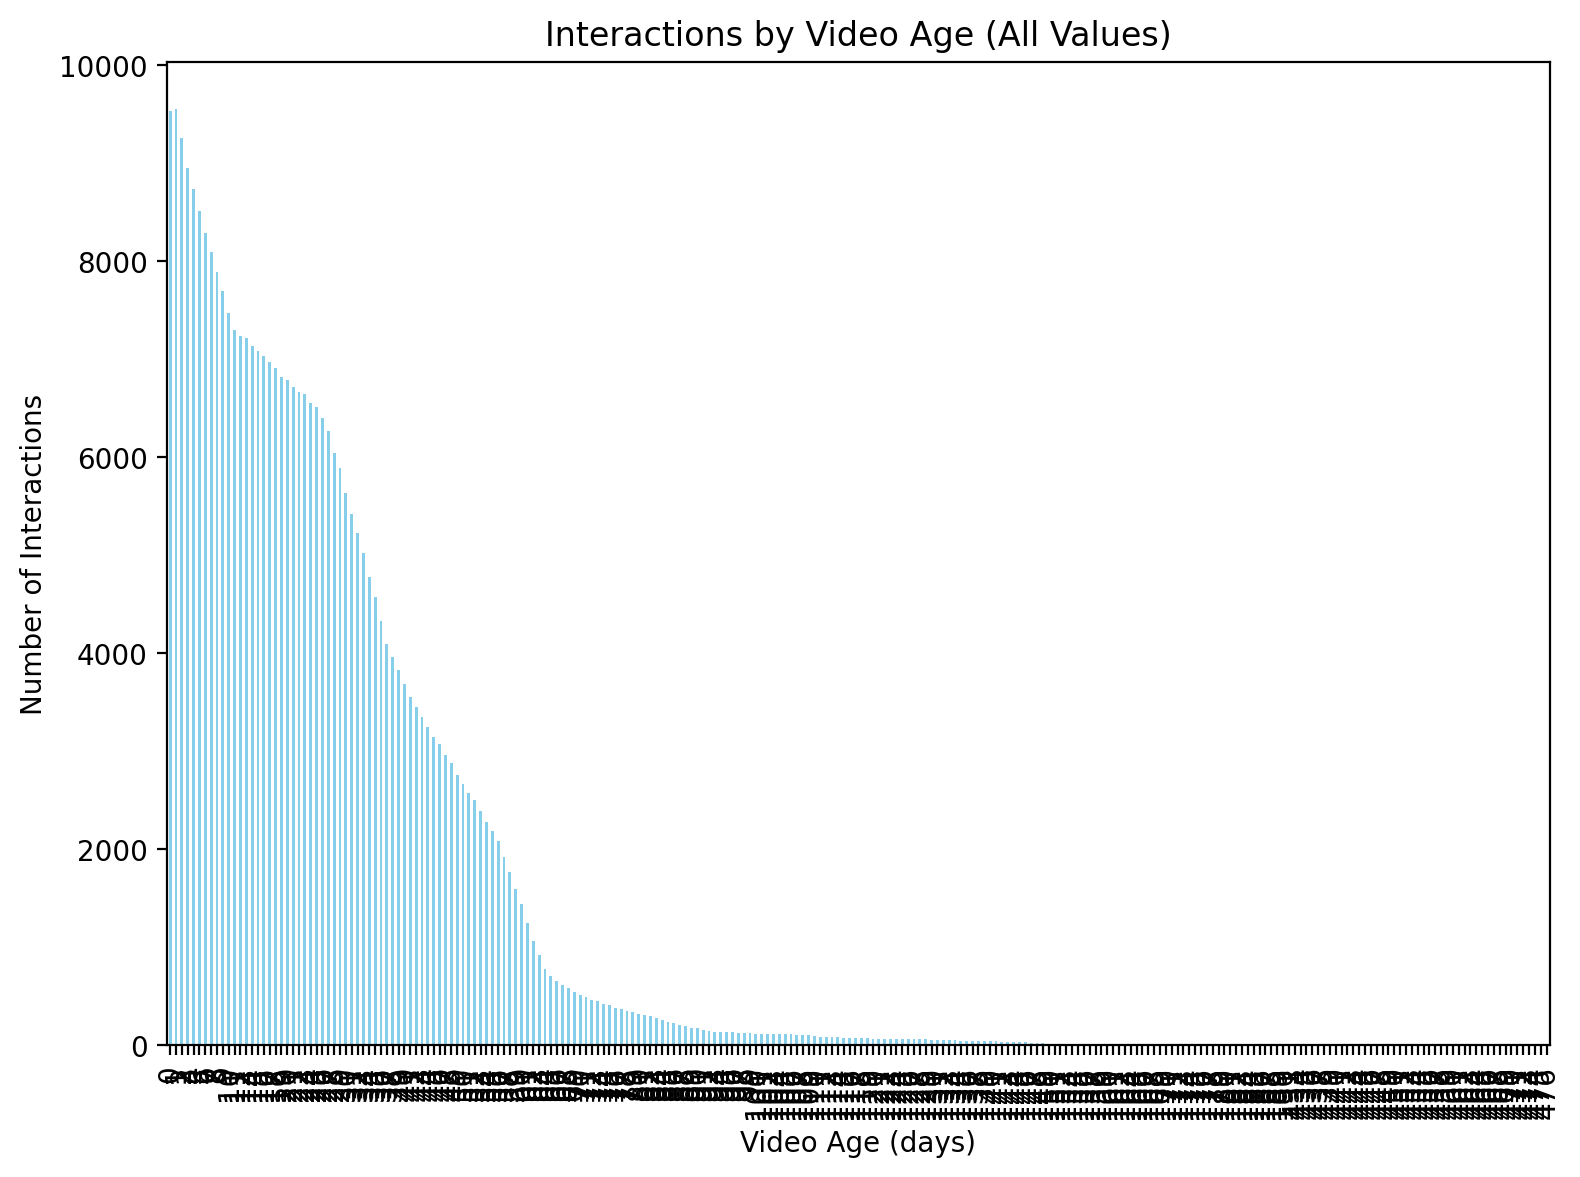

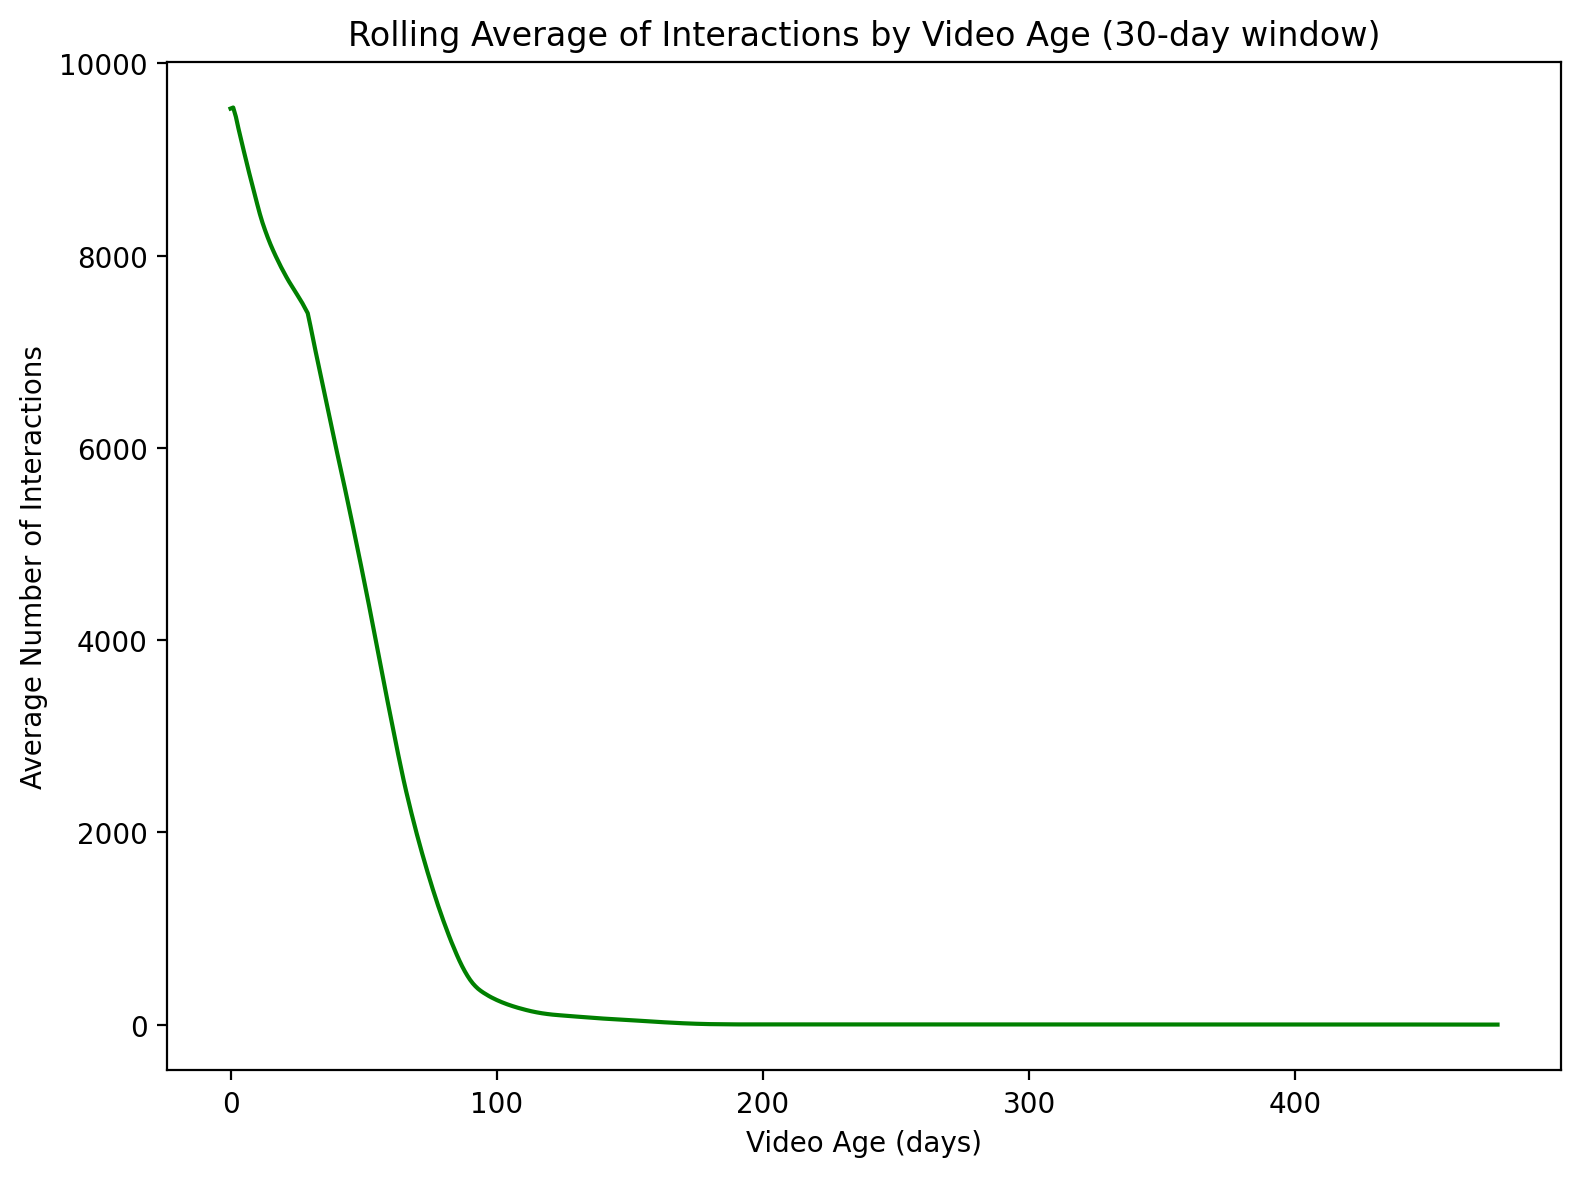

In [44]:
import matplotlib.pyplot as plt

item_features['video_age'] = (item_features['date'] - item_features['upload_dt']).dt.days

# Count interactions by video_age
interaction_counts = item_features['video_age'].value_counts().sort_index()  # Sort by video_age (days)

# Plot 1: All values, sorted by video_age
plt.figure(figsize=(8, 6))
interaction_counts.plot(kind='bar', color='skyblue')
plt.title('Interactions by Video Age (All Values)')
plt.xlabel('Video Age (days)')
plt.ylabel('Number of Interactions')
plt.tight_layout()
plt.show()

# Plot 2: Rolling average with a 30-day window
rolling_avg = interaction_counts.sort_index().rolling(window=30, min_periods=1).mean()

# Plot 3: Rolling average graph
plt.figure(figsize=(8, 6))
rolling_avg.plot(kind='line', color='green')
plt.title('Rolling Average of Interactions by Video Age (30-day window)')
plt.xlabel('Video Age (days)')
plt.ylabel('Average Number of Interactions')
plt.tight_layout()
plt.show()


#### Thinking 🤔
<ins>From the 2 graphs above, we cleary see that :<ins>
- **Recent videos (lower video age in days) tend to have more interactions**, as seen in the bar chart and confirmed by the downward trend in the 30-day rolling average.

## 📝  Observations from the Data
- **Video Type:**

    - **"Ad" videos have significantly lower interaction** rates compared to Normal videos, which are more engaging for users.
    - Users tend to engage less with promotional or advertisement-type content.

- **User Preferences:**

    - There is a clear preference for **Short Imports videos**. These videos are viewed and interacted with more often compared to longer or different upload types.

- **Video Format:**

    - The **1280x720 resolution is the optimal format** for maximizing user interaction and watch ratio. Other formats either fall short or show no significant improvement.

- **Video Privacy Settings:**

    - As expected, **public videos receive more interactions** than private or only friends videos. This could be due to the higher volume of public content being uploaded, which in turn increases the overall interactions.

    - Private or only friends videos tend to have a smaller, more targeted audience, reducing their interaction rates.

- **Video Age**:
    - **Recent videos (lower video age in days) tend to have more interactions**



# **3️⃣  Exploratory Data Analysis - Kuairec Captions**


## 💎 Data Preprocessing

🔍 For this data analysis, we will focus on the **captions and the tags for each video**.

In [20]:
captions = pd.read_csv("../data_final_project/KuaiRec/data/kuairec_caption_category.csv", lineterminator='\n')
captions.drop(columns=["first_level_category_id",
                       "second_level_category_id",
                       "third_level_category_id",
                       ], inplace=True, errors="ignore")
display(captions.head())

,video_id,manual_cover_text,caption,topic_tag,first_level_category_name,second_level_category_name,third_level_category_name
0,0,UNKNOWN,精神小伙路难走 程哥你狗粮慢点撒,[],颜值,颜值随拍,UNKNOWN
1,1,UNKNOWN,NaN,[],高新数码,UNKNOWN,UNKNOWN
2,2,UNKNOWN,晚饭后，运动一下！,[],喜剧,搞笑互动,UNKNOWN
3,3,UNKNOWN,我平淡无奇，惊艳不了时光，温柔不了岁月，我只想漫无目的的走走，努力发笔小财，给自己买花 自己长大.,[],摄影,主题摄影,景物摄影
4,4,五爱街最美美女 一天1q,#搞笑 #感谢快手我要上热门 #五爱市场 这真是完美搭配啊！,"[五爱市场,感谢快手我要上热门,搞笑]",时尚,营销售卖,女装


```Description of the columns present in the dataset :```

| Field Name                | Description                                      | Type  | Example                                                                 |
|---------------------------|--------------------------------------------------|-------|-------------------------------------------------------------------------|
| video_id                  | The ID of the video                             | int64 | 2418                                                                   |
| manual_cover_text         | 封面文字 (added by its author)                  | str   | "愛小可愛崽崽了"                                                        |
| caption                   | 简介说明 (added by its author)                  | str   | "这是什么狗狗，这么可爱的可以这么萌吗？#狗狗的百科全书 ##星座 ##搞笑幽默 ##萌宠视频" |
| topic_tag                | Tags of the topics of this video (added by its author) | str   | "【宠物狗介绍】, 星狗的百科全书, 星座, 搞笑幽默, 萌宠视频"                 |
| first_level_category_id   | First-level category ID                         | int64 | 17                                                                    |
| first_level_category_name | First-level category name                      | str   | "宠物"                                                                 |
| second_level_category_id  | Second-level category ID                        | int64 | 233                                                                   |
| second_level_category_name| Second-level category name                     | str   | "宠物日常记录"                                                         |
| third_level_category_id   | Third-level category ID                         | int64 | 1169                                                                  |
| third_level_category_name | Third-level category name                      | str   | "宠物狗"                                                               |


In the code above we drop the columns `first_level_category_id`, `second_level_category_id`, `third_level_category_id` as we have more complete information with the associated category name `first_level_category_name`, `second_level_category_name`, `third_level_category_name`.

## ❓Basic Questions

In [21]:
print("What is the size of the caption dataset ?")
print(len(captions))

print("How many unique videos ?")
print(captions['video_id'].nunique())

What is the size of the caption dataset ?
10728
How many unique videos ?
10728


In [22]:
print("What is the language of the captions ?")

def detect_language(text):
    try:
        return detect(text)
    except:
        return "UNKNOWN"
    
captions['language'] = captions['caption'].apply(detect_language)

captions['language'].value_counts()

What is the language of the captions ?


language
zh-cn      5924
ko         3233
UNKNOWN    1461
pt           19
vi           16
tl           12
en            9
no            7
ja            5
zh-tw         5
so            4
et            4
sw            4
cy            3
nl            3
it            3
pl            2
hr            2
sl            2
de            2
sv            1
af            1
da            1
ro            1
fi            1
el            1
sq            1
hu            1
Name: count, dtype: int64

In [23]:
captions[captions['language'] == 'en'].head()

,video_id,manual_cover_text,caption,topic_tag,first_level_category_name,second_level_category_name,third_level_category_name,language
2417,2417,UNKNOWN,Baby，你在做what，有没有eat饭，有没有miss我，反正我miss你了，能不能和我s...,[],颜值,颜值随拍,UNKNOWN,en
3502,3502,UNKNOWN,baby你在做what 有没有eat饭 也没有miss我 能不能给me一个,[],颜值,UNKNOWN,UNKNOWN,en
3588,3588,弱者才会一蹶不振 我要逆风翻盘,拜托，不要刷着励志视频，却做着颓废的人.#studuaccount,[studuaccount],生活,UNKNOWN,UNKNOWN,en
5200,5200,UNKNOWN,youllfind other star butlonly onemoon 你会找到别...,[天秤座的女孩],颜值,UNKNOWN,UNKNOWN,en
5233,5233,是时候上才艺啦,跳舞我们是认真的~ #BootyMusic,[BootyMusic],舞蹈,UNKNOWN,UNKNOWN,en


In [24]:
captions[captions['language'] == 'UNKNOWN'].head()

,video_id,manual_cover_text,caption,topic_tag,first_level_category_name,second_level_category_name,third_level_category_name,language
1,1,UNKNOWN,NaN,[],高新数码,UNKNOWN,UNKNOWN,UNKNOWN
9,9,UNKNOWN,NaN,[],自拍,UNKNOWN,UNKNOWN,UNKNOWN
19,19,UNKNOWN,NaN,[],三农,农业与农民,种植业,UNKNOWN
20,20,UNKNOWN,NaN,[],美食,美食日常,美食分享,UNKNOWN
25,25,葬礼？,NaN,[],颜值,UNKNOWN,UNKNOWN,UNKNOWN


As we can see there are mostly Korean and Chinese captions, 
the error can sometimes happen if the caption is unknown or if there are weird characters.


In [25]:
def is_mostly_chinese(text):
    return bool(re.search(r'[\u4e00-\u9fff]', str(text))) and not re.search(r'[\uac00-\ud7a3]', str(text))

def is_mostly_korean(text):
    return bool(re.search(r'[\uac00-\ud7a3]', str(text))) and not re.search(r'[\u4e00-\u9fff]', str(text))

def override_language(row):
    if row['language'] not in ['ko', 'zh-cn']:
        if is_mostly_korean(row['caption']):
            return 'ko'
        elif is_mostly_chinese(row['caption']):
            return 'zh-cn'
    return row['language']

captions['language'] = captions.apply(override_language, axis=1)

In [26]:
captions['caption'].fillna('UNKNOWN', inplace=True)
captions['language'].fillna('UNKNOWN', inplace=True)


/var/folders/pg/1l4d75p90r565jztmcw4v8c00000gn/T/ipykernel_24137/3860148140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  captions['caption'].fillna('UNKNOWN', inplace=True)
/var/folders/pg/1l4d75p90r565jztmcw4v8c00000gn/T/ipykernel_24137/3860148140.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

## 📝  Observations from the Data

We saw that captions are mostly in **chinese and korean**, which is a good insight if we want to recommend video based on the category, but also on similar captions.

# 4️⃣ Conclusion



This is a recap of each of the observations we have made so far :

- **User Interactions**: 
  - The majority of users have **fewer than 3,000 interactions**.
  - There are a few **outliers** with interactions exceeding 6,000.

- **Item Popularity**:
  - There are very few items that receive **high levels of interaction**.
  - Many items, while not extremely popular, still receive a fair amount of attention.
  - A small subset of items are truly **highly popular**.

- **Time-Based Trends**:
  - However, interactions peak towards the **end of the week**, specifically from **Friday to Sunday**.
  - **Late-night hours (0:00 - 3:00 a.m.)** see the highest levels of activity.
  - **From 10:00 to 20:00** we see less activity
  - The time of day or day of the week has **minimal to no impact** on the watch ratio.

- **User Behavior**:
  - The **top 10 most active users** show a distinct dip in activity around **12:00 p.m.** and **4:00 p.m.**.

- **Video Length**:
  - **Shorter videos** (up to 30 seconds) receive **more interactions** and have a **higher watch ratio**.
  - Conversely, **longer videos** tend to have **fewer interactions** and a lower watch ratio.
  - Videos that are **no longer than 30 seconds** appear to have the optimal watch ratio.

- **Video Type:**

    - **"Ad" videos have significantly lower interaction** rates compared to Normal videos, which are more engaging for users.
    - Users tend to engage less with promotional or advertisement-type content.

- **User Preferences:**

    - There is a clear preference for **Short Imports videos**. These videos are viewed and interacted with more often compared to longer or different upload types.

- **Video Format:**

    - The **1280x720 resolution is the optimal format** for maximizing user interaction and watch ratio. Other formats either fall short or show no significant improvement.

- **Video Privacy Settings:**

    - As expected, **public videos receive more interactions** than private or only friends videos. This could be due to the higher volume of public content being uploaded, which in turn increases the overall interactions.

    - Private or only friends videos tend to have a smaller, more targeted audience, reducing their interaction rates.

- **Video Age**:
    - **Recent videos (lower video age in days) tend to have more interactions**